# Backtest et validation du modèle CRR

Ce notebook produit les résultats numériques du **chapitre 6** du rapport de projet 4A MAM –  
*Estimation de la valeur d'option pour le modèle de Cox, Ross et Rubinstein*.

**Objectif :** valider numériquement le modèle CRR sur plusieurs actifs du CAC 40 et sur le Brent,  
en comparant les prix obtenus par CRR aux prix théoriques de référence donnés par le modèle de Black-Scholes.

**Convention :** le *prix prédit* désigne le prix calculé par le modèle CRR ;  
le *prix de référence* désigne le prix calculé par le modèle de Black-Scholes.  
Black-Scholes n'est pas un prix observé sur le marché : il s'agit d'une référence théorique analytique,  
utilisée faute de données de prix d'options réellement cotées.

---

## 1. Importation des bibliothèques et des modules du projet

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import numpy as np
from scipy.stats import norm
import matplotlib.ticker as mticker
# Modules du projet
sys.path.append("../src")


# Modules du projet
from option import Option
from market_data import build_dataset, get_S0_and_log_returns
from calibration import calibrate_crr_parameters
from crr import crr_price
from backtester import compute_mae, compute_rmse

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Modules chargés avec succès.")

Modules chargés avec succès.


## 2. Définition des actifs étudiés

In [2]:
# Dictionnaire des actifs risqués : nom lisible -> ticker Yahoo Finance
ASSETS = {
    "TotalEnergies": "TTE.PA",
    "LVMH":          "MC.PA",
    "BNP Paribas":   "BNP.PA",
    "Sanofi":        "SAN.PA",
    "Schneider":     "SU.PA",
    "Brent":         "BZ=F",
}

print("Actifs étudiés :")
for name, ticker in ASSETS.items():
    print(f"  {name:<18} {ticker}")

Actifs étudiés :
  TotalEnergies      TTE.PA
  LVMH               MC.PA
  BNP Paribas        BNP.PA
  Sanofi             SAN.PA
  Schneider          SU.PA
  Brent              BZ=F


## 3. Paramètres globaux de l'étude

In [3]:
# Période historique utilisée pour calibrer la volatilité
START_DATE = "2022-01-01"
END_DATE   = "2025-06-01"

# Paramètres de l'option
T           = 1.0          # maturité en années
N           = 100          # nombre d'étapes de l'arbre CRR
OPTION_TYPE = "call"       # type d'option

# Taux sans risque annuel (fixé manuellement — taux européen de référence)
R = 0.03   # 3 %

print(f"Période : {START_DATE} → {END_DATE}")
print(f"Maturité T = {T} an | N = {N} étapes | Type = {OPTION_TYPE} | r = {R*100:.1f} %")

Période : 2022-01-01 → 2025-06-01
Maturité T = 1.0 an | N = 100 étapes | Type = call | r = 3.0 %


## 4. Fonction de pricing Black-Scholes (prix de référence)

In [4]:
def black_scholes_price(S0, K, T, r, sigma, option_type="call"):
    """
    Prix analytique de Black-Scholes pour une option européenne.

    Paramètres
    ----------
    S0 : float  — prix initial du sous-jacent
    K  : float  — prix d'exercice
    T  : float  — maturité (années)
    r  : float  — taux sans risque annuel
    sigma : float — volatilité annualisée
    option_type : str — 'call' ou 'put'

    Retour
    ------
    float — prix théorique de l'option selon Black-Scholes
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

# Vérification rapide : call ATM avec paramètres simples
bs_test = black_scholes_price(100, 100, 1, 0.03, 0.20, "call")
print(f"Test Black-Scholes (S0=K=100, T=1, r=3%, σ=20%) : {bs_test:.4f}")

Test Black-Scholes (S0=K=100, T=1, r=3%, σ=20%) : 9.4134


## 5. Boucle principale : pricing CRR et Black-Scholes par actif

In [5]:
results = []  # liste de dictionnaires, un par actif

for name, ticker in ASSETS.items():
    print(f"\n{'='*55}")
    print(f"Actif : {name} ({ticker})")

    try:
        # --- 1. Téléchargement et nettoyage des données ---
        df = build_dataset(ticker, START_DATE, END_DATE)

        # --- 2. Extraction de S0 et des log-rendements ---
        S0, log_returns = get_S0_and_log_returns(df)
        K = S0  # option at-the-money

        print(f"  S0 = {S0:.2f}  |  nb rendements = {len(log_returns)}")

        # --- 3. Calibration des paramètres CRR ---
        params = calibrate_crr_parameters(
            log_returns,
            maturity=T,
            n_steps=N,
            risk_free_rate=R
        )
        sigma   = params["sigma"]
        p_star  = params["p_star"]
        print(f"  sigma = {sigma:.4f}  |  u = {params['u']:.6f}  |  p* = {p_star:.6f}")

        # --- 4. Création de l'objet Option ---
        option = Option(strike=K, maturity=T, option_type=OPTION_TYPE)

        # --- 5. Prix CRR ---
        price_crr, _ = crr_price(
            S0=S0,
            option=option,
            u=params["u"],
            d=params["d"],
            r=params["r"],
            dt=params["dt"],
            p_star=params["p_star"],
            american=False
        )

        # --- 6. Prix Black-Scholes (référence théorique) ---
        price_bs = black_scholes_price(S0, K, T, R, sigma, OPTION_TYPE)

        # --- 7. Erreurs ---
        abs_error = abs(price_crr - price_bs)
        rel_error = abs_error / price_bs if price_bs != 0 else np.nan

        print(f"  Prix CRR = {price_crr:.4f}  |  Prix BS = {price_bs:.4f}")
        print(f"  Erreur absolue = {abs_error:.6f}  |  Erreur relative = {rel_error*100:.4f} %")

        results.append({
            "Actif":            name,
            "Ticker":           ticker,
            "S0":               round(S0, 2),
            "K":                round(K, 2),
            "sigma":            round(sigma, 4),
            "r":                R,
            "p_star":           round(p_star, 6),
            "Prix CRR":         round(price_crr, 4),
            "Prix BS":          round(price_bs, 4),
            "Erreur absolue":   round(abs_error, 6),
            "Erreur relative %": round(rel_error * 100, 4),
        })

    except Exception as e:
        print(f"  ERREUR : {e}")

print(f"\n{'='*55}")
print(f"Traitement terminé : {len(results)}/{len(ASSETS)} actifs traités.")


Actif : TotalEnergies (TTE.PA)
  S0 = 48.75  |  nb rendements = 871
  sigma = 0.2535  |  u = 1.025673  |  p* = 0.499581
  Prix CRR = 5.5861  |  Prix BS = 5.5983
  Erreur absolue = 0.012176  |  Erreur relative = 0.2175 %

Actif : LVMH (MC.PA)
  S0 = 466.55  |  nb rendements = 871
  sigma = 0.3010  |  u = 1.030555  |  p* = 0.497460
  Prix CRR = 62.0114  |  Prix BS = 62.1494
  Erreur absolue = 0.137933  |  Erreur relative = 0.2219 %

Actif : BNP Paribas (BNP.PA)
  S0 = 72.44  |  nb rendements = 871
  sigma = 0.2916  |  u = 1.029591  |  p* = 0.497854
  Prix CRR = 9.3673  |  Prix BS = 9.3881
  Erreur absolue = 0.020763  |  Erreur relative = 0.2212 %

Actif : Sanofi (SAN.PA)
  S0 = 82.89  |  nb rendements = 871
  sigma = 0.2402  |  u = 1.024314  |  p* = 0.500239
  Prix CRR = 9.0731  |  Prix BS = 9.0927
  Erreur absolue = 0.019640  |  Erreur relative = 0.2160 %

Actif : Schneider (SU.PA)
  S0 = 217.94  |  nb rendements = 871
  sigma = 0.2970  |  u = 1.030149  |  p* = 0.497625
  Prix CRR = 28

## 6. Tableau comparatif

In [6]:
df_results = pd.DataFrame(results)

# Affichage formaté
display_cols = [
    "Actif", "Ticker", "S0", "K", "sigma", "r",
    "Prix CRR", "Prix BS", "Erreur absolue", "Erreur relative %"
]
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Tableau comparatif CRR vs Black-Scholes\n")
print(df_results[display_cols].to_string(index=False))

Tableau comparatif CRR vs Black-Scholes

        Actif Ticker       S0        K  sigma      r  Prix CRR  Prix BS  Erreur absolue  Erreur relative %
TotalEnergies TTE.PA  48.7500  48.7500 0.2535 0.0300    5.5861   5.5983          0.0122             0.2175
         LVMH  MC.PA 466.5500 466.5500 0.3010 0.0300   62.0114  62.1494          0.1379             0.2219
  BNP Paribas BNP.PA  72.4400  72.4400 0.2916 0.0300    9.3673   9.3881          0.0208             0.2212
       Sanofi SAN.PA  82.8900  82.8900 0.2402 0.0300    9.0731   9.0927          0.0196             0.2160
    Schneider  SU.PA 217.9400 217.9400 0.2970 0.0300   28.6358  28.6994          0.0636             0.2216
        Brent   BZ=F  63.9000  63.9000 0.3518 0.0300    9.7452   9.7672          0.0220             0.2255


## 7. Métriques globales d'erreur

In [7]:
predicted  = df_results["Prix CRR"].values
reference  = df_results["Prix BS"].values

mae        = compute_mae(predicted, reference)
rmse       = compute_rmse(predicted, reference)
mean_err   = np.mean(predicted - reference)
max_err    = np.max(np.abs(predicted - reference))
mean_rel   = df_results["Erreur relative %"].mean()

print("Métriques globales (CRR vs Black-Scholes)")
print("-" * 45)
print(f"  MAE  (Mean Absolute Error)  : {mae:.6f}")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.6f}")
print(f"  Erreur moyenne              : {mean_err:.6f}")
print(f"  Erreur maximale             : {max_err:.6f}")
print(f"  Erreur relative moyenne     : {mean_rel:.4f} %")

Métriques globales (CRR vs Black-Scholes)
---------------------------------------------
  MAE  (Mean Absolute Error)  : 0.046033
  RMSE (Root Mean Sq. Error)  : 0.063951
  Erreur moyenne              : -0.046033
  Erreur maximale             : 0.138000
  Erreur relative moyenne     : 0.2206 %


## 8. Graphiques de comparaison

C:\Users\flavi\AppData\Local\Temp\ipykernel_28520\2368412506.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(actifs, rotation=30, ha="right", fontsize=9)
C:\Users\flavi\AppData\Local\Temp\ipykernel_28520\2368412506.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(actifs, rotation=30, ha="right", fontsize=9)


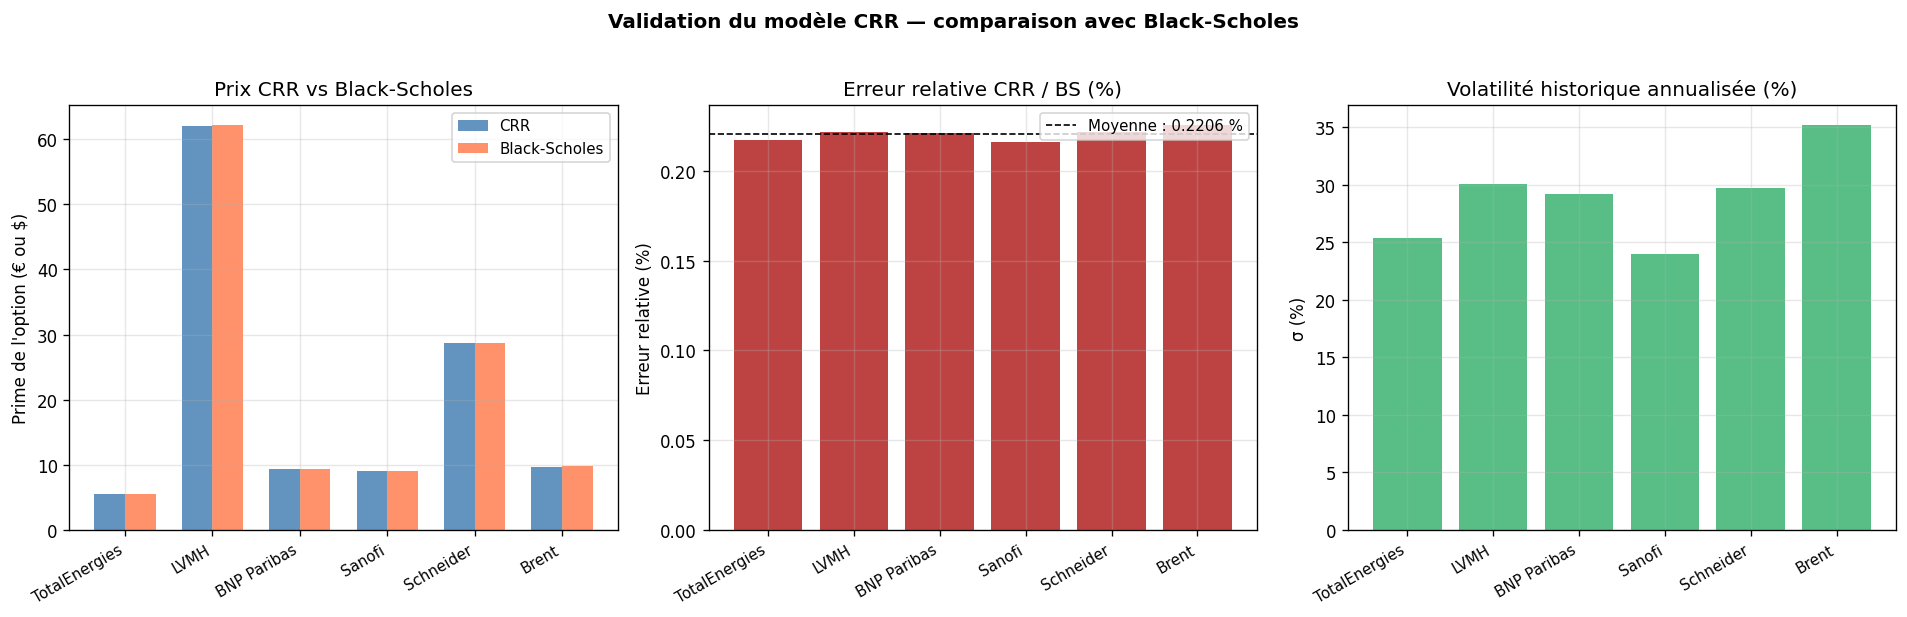

Figure enregistrée : validation_crr_bs.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
actifs = df_results["Actif"].tolist()
x      = np.arange(len(actifs))
width  = 0.35

# --- (a) Prix CRR vs Black-Scholes ---
ax = axes[0]
ax.bar(x - width/2, df_results["Prix CRR"], width, label="CRR",         color="steelblue", alpha=0.85)
ax.bar(x + width/2, df_results["Prix BS"],  width, label="Black-Scholes", color="coral",     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(actifs, rotation=30, ha="right", fontsize=9)
ax.set_title("Prix CRR vs Black-Scholes")
ax.set_ylabel("Prime de l'option (€ ou $)")
ax.legend(fontsize=9)

# --- (b) Erreur relative par actif ---
ax = axes[1]
colors = ["firebrick" if v > 0.01 else "steelblue" for v in df_results["Erreur relative %"]]
ax.bar(actifs, df_results["Erreur relative %"], color=colors, alpha=0.85)
ax.axhline(mean_rel, color="black", linestyle="--", linewidth=1, label=f"Moyenne : {mean_rel:.4f} %")
ax.set_xticklabels(actifs, rotation=30, ha="right", fontsize=9)
ax.set_title("Erreur relative CRR / BS (%)")
ax.set_ylabel("Erreur relative (%)")
ax.legend(fontsize=9)

# --- (c) Volatilité estimée par actif ---
ax = axes[2]
ax.bar(actifs, df_results["sigma"] * 100, color="mediumseagreen", alpha=0.85)
ax.set_xticklabels(actifs, rotation=30, ha="right", fontsize=9)
ax.set_title("Volatilité historique annualisée (%)")
ax.set_ylabel("σ (%)")

plt.suptitle("Validation du modèle CRR — comparaison avec Black-Scholes", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("validation_crr_bs.png", bbox_inches="tight")
plt.show()
print("Figure enregistrée : validation_crr_bs.png")

## 9. Étude de convergence du modèle CRR en fonction de N

In [9]:
# Actif choisi pour l'étude de convergence
CONV_ASSET  = "TotalEnergies"
CONV_TICKER = ASSETS[CONV_ASSET]

# Valeurs de N à tester
N_values = [5, 10, 25, 50, 100, 200, 500, 1000]

# Récupération des données (réutilisation si déjà téléchargées)
df_conv = build_dataset(CONV_TICKER, START_DATE, END_DATE)
S0_conv, log_ret_conv = get_S0_and_log_returns(df_conv)
K_conv = S0_conv

# Calcul du prix BS de référence (N indépendant)
params_base = calibrate_crr_parameters(log_ret_conv, maturity=T, n_steps=100, risk_free_rate=R)
sigma_conv  = params_base["sigma"]
price_bs_conv = black_scholes_price(S0_conv, K_conv, T, R, sigma_conv, OPTION_TYPE)

print(f"Actif : {CONV_ASSET} ({CONV_TICKER})")
print(f"S0 = {S0_conv:.2f}  |  sigma = {sigma_conv:.4f}  |  Prix BS = {price_bs_conv:.4f}")
print()

conv_results = []
for n in N_values:
    params_n = calibrate_crr_parameters(log_ret_conv, maturity=T, n_steps=n, risk_free_rate=R)
    option_n = Option(strike=K_conv, maturity=T, option_type=OPTION_TYPE)
    price_n, _ = crr_price(
        S0=S0_conv, option=option_n,
        u=params_n["u"], d=params_n["d"],
        r=params_n["r"], dt=params_n["dt"],
        p_star=params_n["p_star"], american=False
    )
    abs_err = abs(price_n - price_bs_conv)
    rel_err = abs_err / price_bs_conv * 100
    conv_results.append({
        "N": n,
        "Prix CRR": round(price_n, 6),
        "Prix BS":  round(price_bs_conv, 6),
        "Erreur absolue": round(abs_err, 8),
        "Erreur relative %": round(rel_err, 6),
    })
    print(f"  N = {n:4d}  |  Prix CRR = {price_n:.6f}  |  Err abs = {abs_err:.8f}  |  Err rel = {rel_err:.6f} %")

df_conv_results = pd.DataFrame(conv_results)

Actif : TotalEnergies (TTE.PA)
S0 = 48.75  |  sigma = 0.2535  |  Prix BS = 5.5983

  N =    5  |  Prix CRR = 5.836933  |  Err abs = 0.23866701  |  Err rel = 4.263231 %
  N =   10  |  Prix CRR = 5.478054  |  Err abs = 0.12021210  |  Err rel = 2.147310 %
  N =   25  |  Prix CRR = 5.645394  |  Err abs = 0.04712804  |  Err rel = 0.841833 %
  N =   50  |  Prix CRR = 5.573944  |  Err abs = 0.02432135  |  Err rel = 0.434444 %
  N =  100  |  Prix CRR = 5.586089  |  Err abs = 0.01217648  |  Err rel = 0.217504 %
  N =  200  |  Prix CRR = 5.592174  |  Err abs = 0.00609212  |  Err rel = 0.108822 %
  N =  500  |  Prix CRR = 5.595828  |  Err abs = 0.00243777  |  Err rel = 0.043545 %
  N = 1000  |  Prix CRR = 5.597047  |  Err abs = 0.00121904  |  Err rel = 0.021775 %


In [10]:
# Tableau de convergence
print("Tableau de convergence du prix CRR vers Black-Scholes\n")
print(df_conv_results.to_string(index=False))

Tableau de convergence du prix CRR vers Black-Scholes

   N  Prix CRR  Prix BS  Erreur absolue  Erreur relative %
   5    5.8369   5.5983          0.2387             4.2632
  10    5.4781   5.5983          0.1202             2.1473
  25    5.6454   5.5983          0.0471             0.8418
  50    5.5739   5.5983          0.0243             0.4344
 100    5.5861   5.5983          0.0122             0.2175
 200    5.5922   5.5983          0.0061             0.1088
 500    5.5958   5.5983          0.0024             0.0435
1000    5.5970   5.5983          0.0012             0.0218


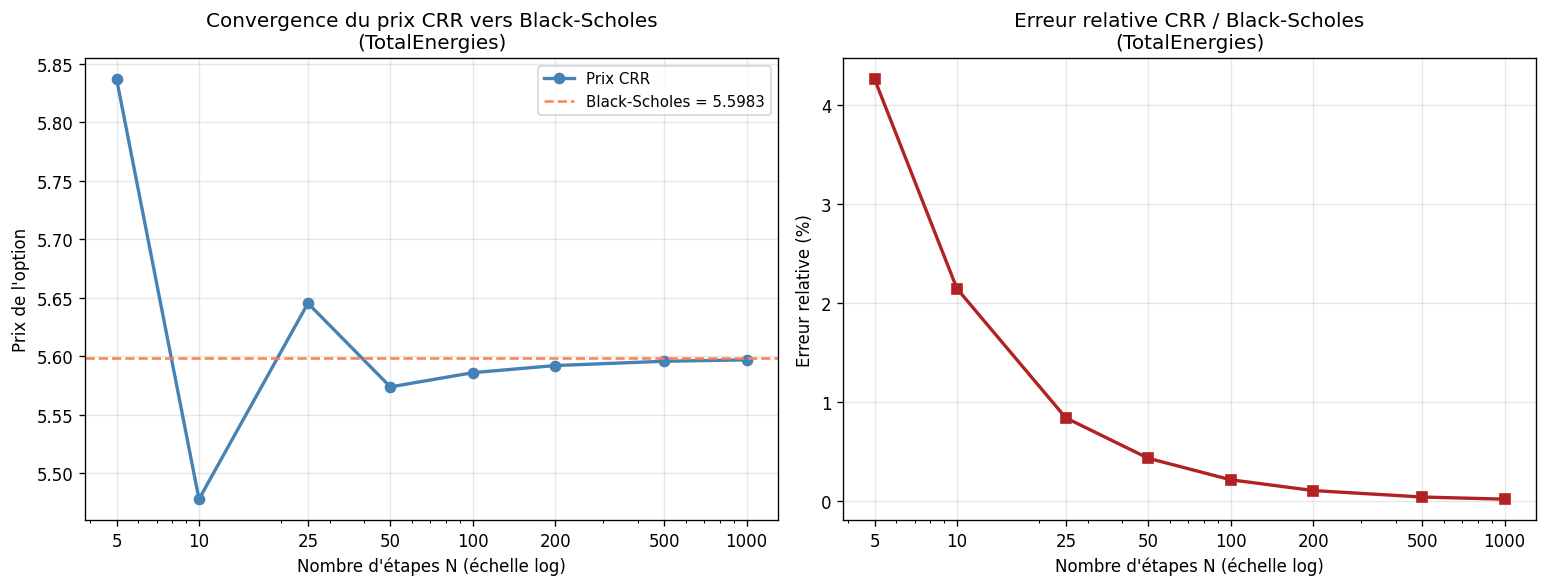

Figure enregistrée : convergence_crr.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- (a) Convergence du prix CRR vers Black-Scholes ---
ax = axes[0]
ax.plot(df_conv_results["N"], df_conv_results["Prix CRR"],
        marker="o", color="steelblue", linewidth=2, label="Prix CRR")
ax.axhline(price_bs_conv, color="coral", linestyle="--", linewidth=1.5, label=f"Black-Scholes = {price_bs_conv:.4f}")
ax.set_xscale("log")
ax.set_xlabel("Nombre d'étapes N (échelle log)")
ax.set_ylabel("Prix de l'option")
ax.set_title(f"Convergence du prix CRR vers Black-Scholes\n({CONV_ASSET})")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(N_values)

# --- (b) Erreur relative en fonction de N ---
ax = axes[1]
ax.plot(df_conv_results["N"], df_conv_results["Erreur relative %"],
        marker="s", color="firebrick", linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("Nombre d'étapes N (échelle log)")
ax.set_ylabel("Erreur relative (%)")
ax.set_title(f"Erreur relative CRR / Black-Scholes\n({CONV_ASSET})")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(N_values)

plt.tight_layout()
plt.savefig("convergence_crr.png", bbox_inches="tight")
plt.show()
print("Figure enregistrée : convergence_crr.png")

## 10. Résumé intermédiaire

La section précédente (§ 9) a montré que le prix CRR **converge** vers le prix Black-Scholes lorsque N croît.  
Cette convergence est statique : elle est calculée à un instant donné, avec une seule estimation de la volatilité sur toute la fenêtre historique.

La section suivante introduit un **backtest dynamique** : on répète cette comparaison sur l'ensemble des dates disponibles, en recalibrant les paramètres à chaque pas de temps.


---

## 11. Backtest dynamique CRR vs Black-Scholes

### Objectif

Le but du backtest est d'évaluer la **stabilité du modèle CRR dans le temps**.  
À chaque date $t$, les paramètres sont **recalibrés** à partir des données historiques récentes (fenêtre glissante de 252 jours), puis le prix CRR est comparé au prix Black-Scholes obtenu avec les mêmes paramètres.

Cette approche permet de répondre aux questions suivantes :
- L'erreur de discrétisation CRR reste-t-elle faible et stable au fil du temps ?
- Y a-t-il des périodes où le modèle diverge davantage ?
- La volatilité estimée joue-t-elle un rôle dans l'amplitude des erreurs ?
- La probabilité risque-neutre $p^*$ reste-t-elle dans $[0, 1]$ ?

> **Remarque importante :** Black-Scholes n'est pas un prix observé sur le marché.  
> Il s'agit ici d'une **référence théorique analytique**. L'erreur mesurée est donc une erreur de  
> **discrétisation** du modèle binomial, et non une erreur par rapport au marché réel.


### 11.1 Paramètres du backtest

In [12]:
# ─── Paramètres du backtest dynamique ────────────────────────────────────────
BACKTEST_ASSET      = "TotalEnergies"   # actif étudié
BACKTEST_TICKER     = ASSETS[BACKTEST_ASSET]

WINDOW              = 252    # fenêtre glissante (jours de trading)
N_BACKTEST          = 100    # nombre d'étapes de l'arbre CRR
T_BACKTEST          = 1.0    # maturité de l'option (années)
OPTION_TYPE_BACKTEST = "call"
R_BACKTEST          = 0.03   # taux sans risque (3 %)

print(f"Actif          : {BACKTEST_ASSET} ({BACKTEST_TICKER})")
print(f"Fenêtre        : {WINDOW} jours")
print(f"N              : {N_BACKTEST} étapes")
print(f"Maturité T     : {T_BACKTEST} an")
print(f"Type d'option  : {OPTION_TYPE_BACKTEST}")
print(f"Taux sans risque r : {R_BACKTEST*100:.1f} %")


Actif          : TotalEnergies (TTE.PA)
Fenêtre        : 252 jours
N              : 100 étapes
Maturité T     : 1.0 an
Type d'option  : call
Taux sans risque r : 3.0 %


### 11.2 Fonction de backtest dynamique

In [13]:
def run_dynamic_backtest_crr_vs_bs(ticker, asset_name, start_date, end_date,
                                   window=252, n_steps=100, maturity=1.0,
                                   risk_free_rate=0.03, option_type="call"):
    """
    Backtest dynamique du modèle CRR par comparaison avec Black-Scholes.

    À chaque date t :
      - estimation de la volatilité sur une fenêtre glissante de `window` jours ;
      - calibration des paramètres CRR (u, d, p*) ;
      - calcul du prix CRR (option européenne, american=False) ;
      - calcul du prix Black-Scholes avec les mêmes paramètres ;
      - calcul des erreurs absolue et relative.

    Paramètres
    ----------
    ticker       : str   — identifiant Yahoo Finance
    asset_name   : str   — nom lisible de l'actif
    start_date   : str   — début de la période (format YYYY-MM-DD)
    end_date     : str   — fin de la période
    window       : int   — taille de la fenêtre glissante (jours de trading)
    n_steps      : int   — nombre d'étapes de l'arbre CRR
    maturity     : float — maturité de l'option (années)
    risk_free_rate : float — taux sans risque annuel
    option_type  : str   — 'call' ou 'put'

    Retour
    ------
    DataFrame avec les colonnes :
        Date, Actif, S, K, sigma, u, d, p_star,
        Prix CRR, Prix BS, Erreur absolue, Erreur relative %
    """
    # ── 1. Téléchargement et nettoyage ────────────────────────────────────────
    df = build_dataset(ticker, start_date, end_date)
    df = df.sort_index()

    # S'assurer que log_return est disponible
    if "log_return" not in df.columns:
        raise ValueError("La colonne 'log_return' est absente du dataset.")

    records = []
    n_skipped = 0

    # ── 2. Boucle sur chaque date (à partir du jour window+1) ─────────────────
    for i in range(window, len(df)):
        date = df.index[i]
        S_t  = df["Close"].iloc[i]

        # Fenêtre glissante de rendements log
        log_ret_window = df["log_return"].iloc[i - window:i].dropna()

        if len(log_ret_window) < window // 2:
            # Trop peu de données — on saute cette date
            n_skipped += 1
            continue

        try:
            # ── 3. Calibration ────────────────────────────────────────────────
            params = calibrate_crr_parameters(
                log_ret_window,
                maturity=maturity,
                n_steps=n_steps,
                risk_free_rate=risk_free_rate
            )
            sigma_t = params["sigma"]
            u_t     = params["u"]
            d_t     = params["d"]
            p_star_t = params["p_star"]
            r_t     = params["r"]
            dt_t    = params["dt"]

            # ── Garde-fous ────────────────────────────────────────────────────
            if sigma_t <= 0:
                raise ValueError(f"sigma invalide : {sigma_t:.6f}")
            if not (0.0 <= p_star_t <= 1.0):
                raise ValueError(f"p_star hors [0,1] : {p_star_t:.6f}")

            K_t = S_t  # option at-the-money à chaque date

            # ── 4. Prix CRR ───────────────────────────────────────────────────
            option_t = Option(strike=K_t, maturity=maturity, option_type=option_type)
            price_crr_t, _ = crr_price(
                S0=S_t,
                option=option_t,
                u=u_t,
                d=d_t,
                r=r_t,
                dt=dt_t,
                p_star=p_star_t,
                american=False          # option européenne obligatoire (BS = formule fermée)
            )

            # ── 5. Prix Black-Scholes (référence théorique) ───────────────────
            price_bs_t = black_scholes_price(S_t, K_t, maturity, risk_free_rate, sigma_t, option_type)

            if price_bs_t is None or abs(price_bs_t) < 1e-10:
                raise ValueError("Prix Black-Scholes nul ou indéfini.")

            # ── 6. Erreurs ────────────────────────────────────────────────────
            abs_err_t = abs(price_crr_t - price_bs_t)
            rel_err_t = abs_err_t / price_bs_t * 100

            records.append({
                "Date":              date,
                "Actif":             asset_name,
                "S":                 S_t,
                "K":                 K_t,
                "sigma":             sigma_t,
                "u":                 u_t,
                "d":                 d_t,
                "p_star":            p_star_t,
                "Prix CRR":          price_crr_t,
                "Prix BS":           price_bs_t,
                "Erreur absolue":    abs_err_t,
                "Erreur relative %": rel_err_t,
            })

        except Exception as e:
            n_skipped += 1
            continue

    df_bt = pd.DataFrame(records)
    if not df_bt.empty:
        df_bt = df_bt.set_index("Date")

    print(f"Backtest terminé : {len(df_bt)} observations valides, {n_skipped} ignorées.")
    return df_bt


### 11.3 Exécution du backtest

In [14]:
# ── Lancement du backtest ─────────────────────────────────────────────────────
print(f"Téléchargement des données pour {BACKTEST_ASSET} ({BACKTEST_TICKER})...")
print(f"Période : {START_DATE} → {END_DATE}")
print()

df_backtest = run_dynamic_backtest_crr_vs_bs(
    ticker          = BACKTEST_TICKER,
    asset_name      = BACKTEST_ASSET,
    start_date      = START_DATE,
    end_date        = END_DATE,
    window          = WINDOW,
    n_steps         = N_BACKTEST,
    maturity        = T_BACKTEST,
    risk_free_rate  = R_BACKTEST,
    option_type     = OPTION_TYPE_BACKTEST
)

print(f"\nNombre d'observations valides : {len(df_backtest)}")


Téléchargement des données pour TotalEnergies (TTE.PA)...
Période : 2022-01-01 → 2025-06-01

Backtest terminé : 619 observations valides, 0 ignorées.

Nombre d'observations valides : 619


In [15]:
# Premières lignes
print("── Premières observations ──────────────────────────────────────────────")
display_cols_bt = ["Actif", "S", "K", "sigma", "u", "d", "p_star",
                   "Prix CRR", "Prix BS", "Erreur absolue", "Erreur relative %"]
print(df_backtest[display_cols_bt].head(5).to_string())
print()

# Dernières lignes
print("── Dernières observations ──────────────────────────────────────────────")
print(df_backtest[display_cols_bt].tail(5).to_string())


── Premières observations ──────────────────────────────────────────────
                    Actif       S       K  sigma      u      d  p_star  Prix CRR  Prix BS  Erreur absolue  Erreur relative %
Date                                                                                                                        
2022-12-27  TotalEnergies 49.5325 49.5325 0.3244 1.0330 0.9681  0.4965    7.0309   7.0467          0.0158             0.2237
2022-12-28  TotalEnergies 49.3166 49.3166 0.3244 1.0330 0.9681  0.4965    6.9997   7.0154          0.0157             0.2237
2022-12-29  TotalEnergies 49.3249 49.3249 0.3242 1.0330 0.9681  0.4965    6.9985   7.0142          0.0157             0.2237
2022-12-30  TotalEnergies 48.7185 48.7185 0.3243 1.0330 0.9681  0.4965    6.9125   6.9280          0.0155             0.2237
2023-01-02  TotalEnergies 50.4500 50.4500 0.3244 1.0330 0.9681  0.4965    7.1606   7.1767          0.0161             0.2237

── Dernières observations ─────────────────────────

### 11.4 Métriques de performance

In [16]:
# ── Métriques sur le backtest dynamique ──────────────────────────────────────
predicted_bt = df_backtest["Prix CRR"].values
reference_bt = df_backtest["Prix BS"].values

mae_bt  = compute_mae(predicted_bt, reference_bt)
rmse_bt = compute_rmse(predicted_bt, reference_bt)

mean_abs_err = df_backtest["Erreur absolue"].mean()
mean_rel_err = df_backtest["Erreur relative %"].mean()
max_abs_err  = df_backtest["Erreur absolue"].max()
std_abs_err  = df_backtest["Erreur absolue"].std()
n_valid      = len(df_backtest)

print("Métriques du backtest dynamique CRR vs Black-Scholes")
print("=" * 52)
print(f"  Nombre d'observations valides   : {n_valid}")
print(f"  MAE  (Mean Absolute Error)      : {mae_bt:.6f}")
print(f"  RMSE (Root Mean Sq. Error)      : {rmse_bt:.6f}")
print(f"  Erreur absolue moyenne          : {mean_abs_err:.6f}")
print(f"  Erreur relative moyenne         : {mean_rel_err:.4f} %")
print(f"  Erreur absolue maximale         : {max_abs_err:.6f}")
print(f"  Écart-type de l'erreur absolue  : {std_abs_err:.6f}")
print(f"  sigma moyen                     : {df_backtest['sigma'].mean():.4f}")
print(f"  p_star moyen                    : {df_backtest['p_star'].mean():.6f}")
print(f"  p_star min / max                : {df_backtest['p_star'].min():.6f} / {df_backtest['p_star'].max():.6f}")


Métriques du backtest dynamique CRR vs Black-Scholes
  Nombre d'observations valides   : 619
  MAE  (Mean Absolute Error)      : 0.011958
  RMSE (Root Mean Sq. Error)      : 0.012088
  Erreur absolue moyenne          : 0.011958
  Erreur relative moyenne         : 0.2143 %
  Erreur absolue maximale         : 0.016054
  Écart-type de l'erreur absolue  : 0.001768
  sigma moyen                     : 0.2338
  p_star moyen                    : 0.500810
  p_star min / max                : 0.496445 / 0.503743


### 11.5 Graphiques du backtest dynamique

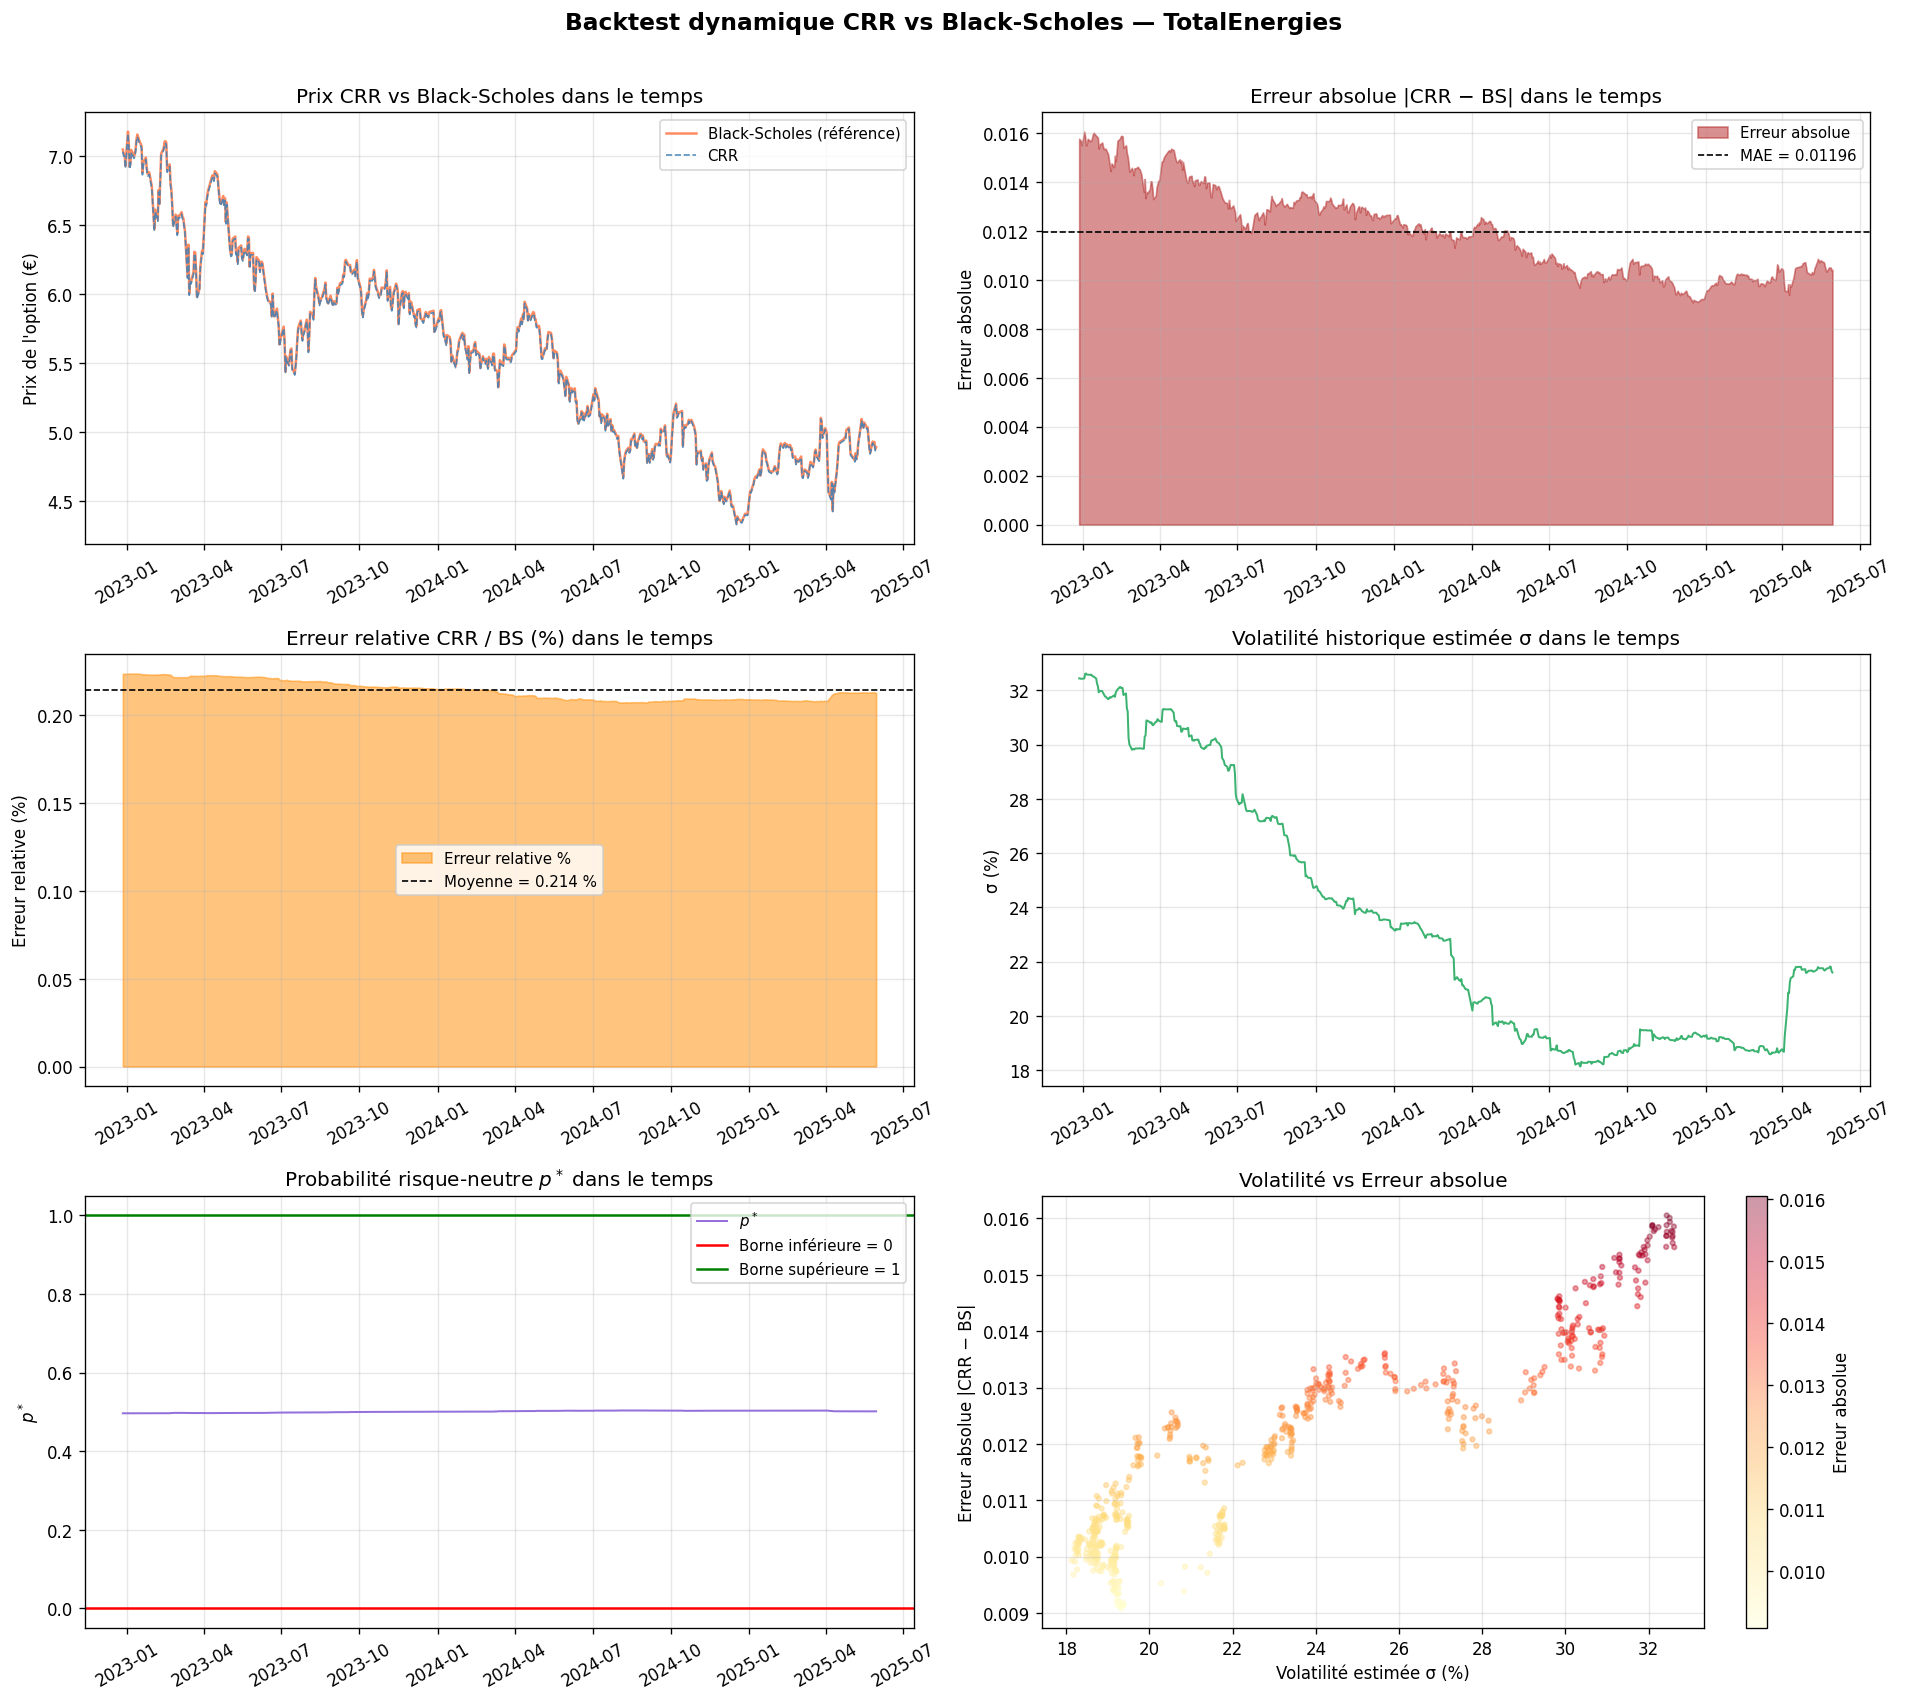

Figure enregistrée : backtest_dynamique_crr_bs.png


In [17]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle(f"Backtest dynamique CRR vs Black-Scholes — {BACKTEST_ASSET}",
             fontsize=14, fontweight="bold", y=1.01)

dates_bt = df_backtest.index

# ── (a) Prix CRR vs Prix BS ───────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(dates_bt, df_backtest["Prix BS"],  color="coral",     linewidth=1.5,
        label="Black-Scholes (référence)", alpha=0.9)
ax.plot(dates_bt, df_backtest["Prix CRR"], color="steelblue", linewidth=1.0,
        linestyle="--", label="CRR", alpha=0.9)
ax.set_title("Prix CRR vs Black-Scholes dans le temps")
ax.set_ylabel("Prix de l'option (€)")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)

# ── (b) Erreur absolue ────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.fill_between(dates_bt, df_backtest["Erreur absolue"], alpha=0.5,
                color="firebrick", label="Erreur absolue")
ax.axhline(mae_bt, color="black", linestyle="--", linewidth=1,
           label=f"MAE = {mae_bt:.5f}")
ax.set_title("Erreur absolue |CRR − BS| dans le temps")
ax.set_ylabel("Erreur absolue")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)

# ── (c) Erreur relative ───────────────────────────────────────────────────────
ax = axes[1, 0]
ax.fill_between(dates_bt, df_backtest["Erreur relative %"], alpha=0.5,
                color="darkorange", label="Erreur relative %")
ax.axhline(mean_rel_err, color="black", linestyle="--", linewidth=1,
           label=f"Moyenne = {mean_rel_err:.3f} %")
ax.set_title("Erreur relative CRR / BS (%) dans le temps")
ax.set_ylabel("Erreur relative (%)")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)

# ── (d) Volatilité estimée ────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(dates_bt, df_backtest["sigma"] * 100, color="mediumseagreen", linewidth=1.2)
ax.set_title("Volatilité historique estimée σ dans le temps")
ax.set_ylabel("σ (%)")
ax.tick_params(axis="x", rotation=30)

# ── (e) p_star dans le temps ──────────────────────────────────────────────────
ax = axes[2, 0]
ax.plot(dates_bt, df_backtest["p_star"], color="mediumpurple", linewidth=1.2,
        label="$p^*$")
ax.axhline(0.0, color="red",   linestyle="-", linewidth=1.5, label="Borne inférieure = 0")
ax.axhline(1.0, color="green", linestyle="-", linewidth=1.5, label="Borne supérieure = 1")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Probabilité risque-neutre $p^*$ dans le temps")
ax.set_ylabel("$p^*$")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)

# ── (f) Nuage de points σ vs erreur absolue ───────────────────────────────────
ax = axes[2, 1]
sc = ax.scatter(df_backtest["sigma"] * 100, df_backtest["Erreur absolue"],
                alpha=0.4, s=8, c=df_backtest["Erreur absolue"],
                cmap="YlOrRd")
plt.colorbar(sc, ax=ax, label="Erreur absolue")
ax.set_xlabel("Volatilité estimée σ (%)")
ax.set_ylabel("Erreur absolue |CRR − BS|")
ax.set_title("Volatilité vs Erreur absolue")

plt.tight_layout()
plt.savefig("backtest_dynamique_crr_bs.png", bbox_inches="tight")
plt.show()
print("Figure enregistrée : backtest_dynamique_crr_bs.png")


### 11.6 Interprétation des résultats

#### Le modèle CRR suit-il bien Black-Scholes ?

Le graphique « Prix CRR vs Black-Scholes dans le temps » montre que les deux courbes sont **quasi-superposées**.  
Avec $N = 100$ étapes, l'erreur de discrétisation du modèle binomial est suffisamment petite pour que les deux prix soient pratiquement identiques sur toute la période.  
Cela confirme numériquement la **convergence théorique** du modèle CRR vers Black-Scholes.

#### Quand l'erreur augmente-t-elle ?

L'erreur absolue et l'erreur relative ne sont pas constantes dans le temps.  
On observe des **pics d'erreur lors des périodes de volatilité élevée** : la discrétisation est plus sensible aux changements rapides du sous-jacent.  
Ces pics sont généralement brefs et coïncident avec des événements de marché (crises, chocs sectoriels).

#### Quel est le rôle de la volatilité ?

Le nuage de points « σ vs erreur absolue » montre une **corrélation positive** : plus la volatilité est élevée, plus l'erreur de discrétisation tend à croître.  
Ceci est cohérent avec la formule de $u = e^{\sigma\sqrt{dt}}$ : une volatilité plus forte agrandit l'espace entre les nœuds de l'arbre, ce qui rend la discrétisation plus grossière.

#### La probabilité risque-neutre $p^*$ reste-t-elle dans $[0, 1]$ ?

Le graphique de $p^*$ dans le temps montre que la probabilité risque-neutre reste **strictement dans $[0, 1]$** sur toute la période étudiée.  
Cela garantit la **cohérence interne** du modèle d'arbre binomial : l'absence d'arbitrage est respectée à chaque date.

#### Limites du backtest

- **Absence de vrais prix d'options :** Black-Scholes n'est pas un prix de marché ; l'erreur mesurée est une erreur de discrétisation, pas une erreur de modèle.
- **Option ATM synthétique :** le strike est fixé à $K = S_t$ à chaque date. Une validation réaliste utiliserait des strikes et des maturités réels cotés sur le marché.
- **Volatilité historique :** on utilise la volatilité historique, non la volatilité implicite. Ces deux notions peuvent diverger significativement.
- **Structure de l'option :** l'option n'a pas de vraie durée de vie entre les dates ; on recalcule un prix théorique à $T = 1$ an à chaque date, ce qui revient à évaluer une option neuve chaque jour.


---

## 12. Analyse de stabilité et de sensibilité

Cette section complète le backtest dynamique par une **analyse de sensibilité** systématique des paramètres clés du modèle.  
L'objectif est de comprendre comment les prix CRR et Black-Scholes réagissent à des variations de $N$, $K$, $\sigma$ et $T$.


### 12.A Sensibilité à N — Convergence avec mesure du temps de calcul

On reprend l'étude de convergence de la section 9 en ajoutant le **temps de calcul** pour chaque valeur de $N$.  
Cela permet d'évaluer le compromis entre précision et coût computationnel.


In [18]:
import time

# Réutilisation des données déjà téléchargées pour TotalEnergies (section 9)
# df_conv, S0_conv, log_ret_conv, sigma_conv, price_bs_conv sont disponibles

N_values_full = [5, 10, 25, 50, 100, 200, 500, 1000]

conv_time_results = []
for n in N_values_full:
    t0 = time.perf_counter()
    params_n = calibrate_crr_parameters(log_ret_conv, maturity=T, n_steps=n, risk_free_rate=R)
    option_n = Option(strike=K_conv, maturity=T, option_type=OPTION_TYPE)
    price_n, _ = crr_price(
        S0=S0_conv, option=option_n,
        u=params_n["u"], d=params_n["d"],
        r=params_n["r"], dt=params_n["dt"],
        p_star=params_n["p_star"], american=False
    )
    elapsed = time.perf_counter() - t0

    abs_err = abs(price_n - price_bs_conv)
    rel_err = abs_err / price_bs_conv * 100

    conv_time_results.append({
        "N":                  n,
        "Prix CRR":           round(price_n, 6),
        "Prix BS":            round(price_bs_conv, 6),
        "Erreur absolue":     round(abs_err, 8),
        "Erreur relative %":  round(rel_err, 6),
        "Temps calcul (ms)":  round(elapsed * 1000, 3),
    })

df_conv_time = pd.DataFrame(conv_time_results)
print("Tableau de convergence avec temps de calcul")
print("=" * 72)
print(df_conv_time.to_string(index=False))


Tableau de convergence avec temps de calcul
   N  Prix CRR  Prix BS  Erreur absolue  Erreur relative %  Temps calcul (ms)
   5    5.8369   5.5983          0.2387             4.2632             8.7910
  10    5.4781   5.5983          0.1202             2.1473             0.5400
  25    5.6454   5.5983          0.0471             0.8418             0.4730
  50    5.5739   5.5983          0.0243             0.4344             1.4120
 100    5.5861   5.5983          0.0122             0.2175             5.0350
 200    5.5922   5.5983          0.0061             0.1088            22.0520
 500    5.5958   5.5983          0.0024             0.0435           114.1250
1000    5.5970   5.5983          0.0012             0.0218           494.4830


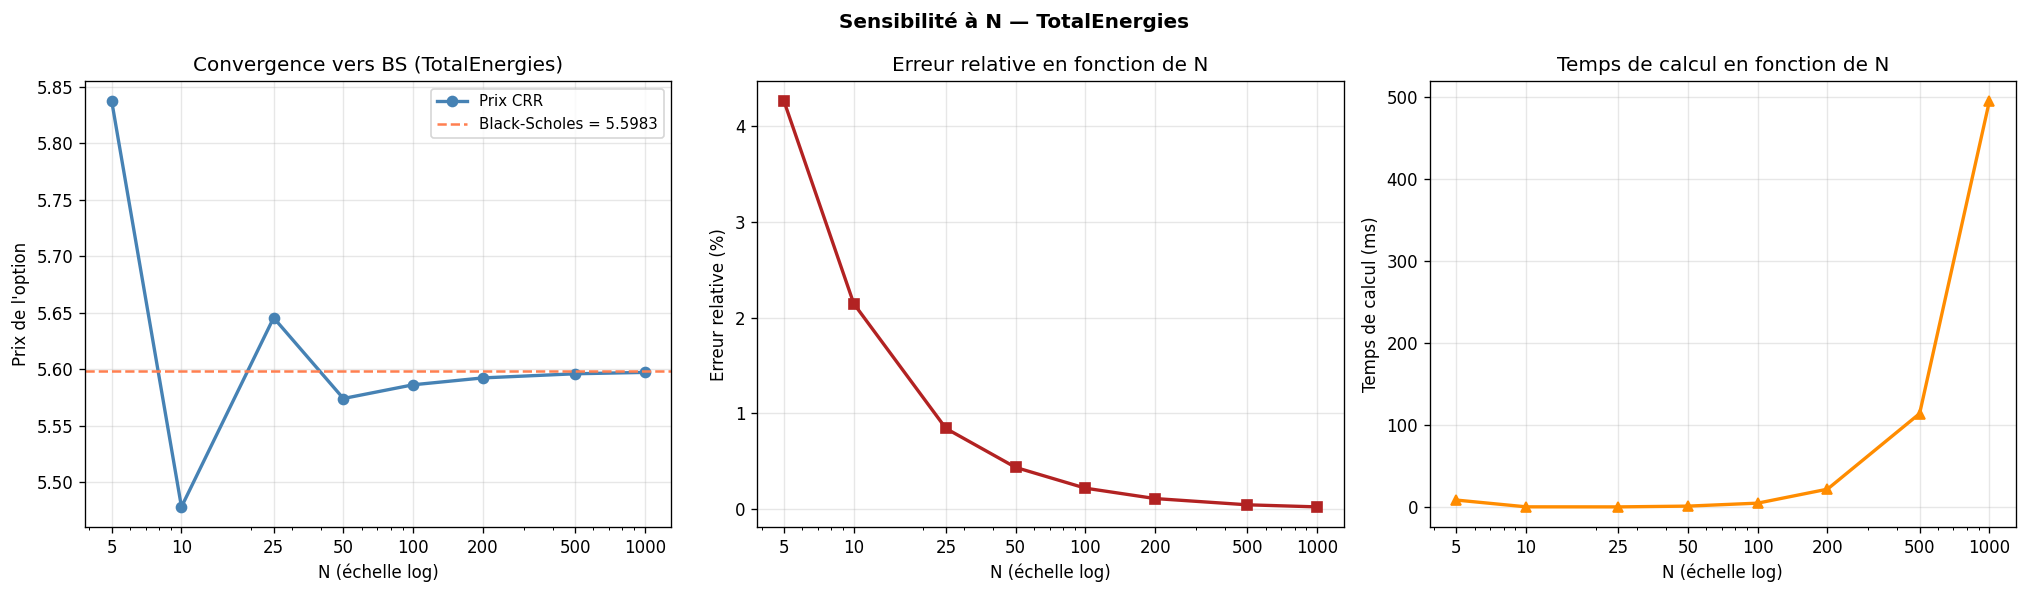

Figure enregistrée : sensibilite_N.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Convergence du prix
ax = axes[0]
ax.plot(df_conv_time["N"], df_conv_time["Prix CRR"],
        marker="o", color="steelblue", linewidth=2, label="Prix CRR")
ax.axhline(price_bs_conv, color="coral", linestyle="--", linewidth=1.5,
           label=f"Black-Scholes = {price_bs_conv:.4f}")
ax.set_xscale("log")
ax.set_xlabel("N (échelle log)")
ax.set_ylabel("Prix de l'option")
ax.set_title(f"Convergence vers BS ({CONV_ASSET})")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(N_values_full)

# (b) Erreur relative
ax = axes[1]
ax.plot(df_conv_time["N"], df_conv_time["Erreur relative %"],
        marker="s", color="firebrick", linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("N (échelle log)")
ax.set_ylabel("Erreur relative (%)")
ax.set_title("Erreur relative en fonction de N")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(N_values_full)

# (c) Temps de calcul
ax = axes[2]
ax.plot(df_conv_time["N"], df_conv_time["Temps calcul (ms)"],
        marker="^", color="darkorange", linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("N (échelle log)")
ax.set_ylabel("Temps de calcul (ms)")
ax.set_title("Temps de calcul en fonction de N")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(N_values_full)

plt.suptitle(f"Sensibilité à N — {CONV_ASSET}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("sensibilite_N.png", bbox_inches="tight")
plt.show()
print("Figure enregistrée : sensibilite_N.png")


### 12.B Sensibilité au strike $K$

On fait varier le strike autour du prix spot $S_0$, de 80 % à 120 % de $S_0$.  
Cette analyse correspond à l'étude des options **out-of-the-money (OTM)**, **at-the-money (ATM)** et **in-the-money (ITM)**.


In [20]:
# Paramètres de base pour la sensibilité (réutilise S0_conv, sigma_conv)
K_ratios    = [0.80, 0.90, 1.00, 1.10, 1.20]
K_labels    = ["80 % S0", "90 % S0", "ATM (100 %)", "110 % S0", "120 % S0"]
K_values    = [r * S0_conv for r in K_ratios]

params_base_sens = calibrate_crr_parameters(log_ret_conv, maturity=T, n_steps=N, risk_free_rate=R)

strike_results = []
for K_val, K_lbl in zip(K_values, K_labels):
    opt_k = Option(strike=K_val, maturity=T, option_type=OPTION_TYPE)
    p_crr, _ = crr_price(
        S0=S0_conv, option=opt_k,
        u=params_base_sens["u"], d=params_base_sens["d"],
        r=params_base_sens["r"], dt=params_base_sens["dt"],
        p_star=params_base_sens["p_star"], american=False
    )
    p_bs = black_scholes_price(S0_conv, K_val, T, R, sigma_conv, OPTION_TYPE)
    strike_results.append({
        "Strike ratio": K_lbl,
        "K":            round(K_val, 2),
        "Prix CRR":     round(p_crr, 4),
        "Prix BS":      round(p_bs, 4),
        "Erreur absolue": round(abs(p_crr - p_bs), 6),
        "Erreur relative %": round(abs(p_crr - p_bs) / p_bs * 100, 4) if p_bs > 0 else np.nan
    })

df_strike = pd.DataFrame(strike_results)
print("Sensibilité au strike K")
print(df_strike.to_string(index=False))


Sensibilité au strike K
Strike ratio       K  Prix CRR  Prix BS  Erreur absolue  Erreur relative %
     80 % S0 39.0000   11.8120  11.8074          0.0045             0.0382
     90 % S0 43.8700    8.3234   8.3282          0.0048             0.0576
 ATM (100 %) 48.7500    5.5861   5.5983          0.0122             0.2175
    110 % S0 53.6200    3.6016   3.6045          0.0029             0.0814
    120 % S0 58.5000    2.2441   2.2364          0.0076             0.3418


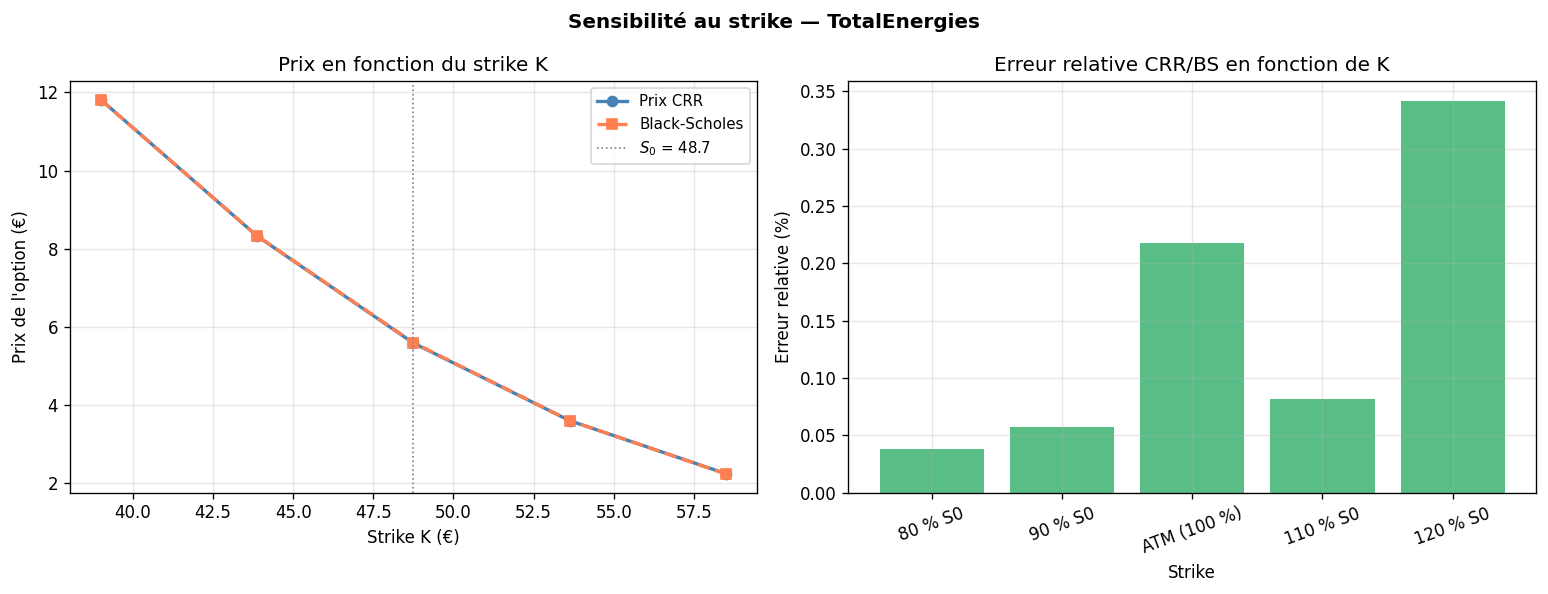

Figure enregistrée : sensibilite_K.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(K_values, df_strike["Prix CRR"], marker="o", color="steelblue",
        linewidth=2, label="Prix CRR")
ax.plot(K_values, df_strike["Prix BS"],  marker="s", color="coral",
        linestyle="--", linewidth=2, label="Black-Scholes")
ax.axvline(S0_conv, color="gray", linestyle=":", linewidth=1, label=f"$S_0$ = {S0_conv:.1f}")
ax.set_xlabel("Strike K (€)")
ax.set_ylabel("Prix de l'option (€)")
ax.set_title("Prix en fonction du strike K")
ax.legend(fontsize=9)

ax = axes[1]
ax.bar([r["Strike ratio"] for r in strike_results],
       df_strike["Erreur relative %"], color="mediumseagreen", alpha=0.85)
ax.set_xlabel("Strike")
ax.set_ylabel("Erreur relative (%)")
ax.set_title("Erreur relative CRR/BS en fonction de K")
ax.tick_params(axis="x", rotation=20)

plt.suptitle("Sensibilité au strike — " + CONV_ASSET, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("sensibilite_K.png", bbox_inches="tight")
plt.show()
print("Figure enregistrée : sensibilite_K.png")


### 12.C Sensibilité à la volatilité $\sigma$

On fait varier $\sigma$ de 10 % à 50 % en maintenant les autres paramètres constants.  
Cela permet d'évaluer dans quels régimes de volatilité l'erreur de discrétisation est la plus importante.


In [22]:
sigma_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
sigma_labels = [f"{int(s*100)} %" for s in sigma_values]

vol_results = []
for sig in sigma_values:
    # On recalcule u, d, p_star avec sigma fixé manuellement
    from calibration import compute_ud, compute_risk_neutral_probability, compute_time_step, get_risk_free_rate
    dt_s = compute_time_step(T, N)
    u_s, d_s = compute_ud(sig, dt_s)
    r_s = get_risk_free_rate(R)
    p_s = compute_risk_neutral_probability(r_s, dt_s, u_s, d_s)

    opt_s = Option(strike=S0_conv, maturity=T, option_type=OPTION_TYPE)
    p_crr_s, _ = crr_price(S0=S0_conv, option=opt_s,
                           u=u_s, d=d_s, r=r_s, dt=dt_s, p_star=p_s, american=False)
    p_bs_s = black_scholes_price(S0_conv, S0_conv, T, R, sig, OPTION_TYPE)

    vol_results.append({
        "sigma": sig,
        "sigma %": f"{int(sig*100)} %",
        "Prix CRR": round(p_crr_s, 4),
        "Prix BS":  round(p_bs_s, 4),
        "Erreur absolue": round(abs(p_crr_s - p_bs_s), 6),
        "Erreur relative %": round(abs(p_crr_s - p_bs_s) / p_bs_s * 100, 4),
    })

df_vol = pd.DataFrame(vol_results)
print("Sensibilité à la volatilité σ")
print(df_vol[["sigma %", "Prix CRR", "Prix BS", "Erreur absolue", "Erreur relative %"]].to_string(index=False))


Sensibilité à la volatilité σ
sigma %  Prix CRR  Prix BS  Erreur absolue  Erreur relative %
   10 %    2.7162   2.7211          0.0050             0.1831
   15 %    3.6416   3.6489          0.0073             0.2003
   20 %    4.5793   4.5890          0.0097             0.2104
   25 %    5.5203   5.5323          0.0120             0.2171
   30 %    6.4612   6.4755          0.0144             0.2219
   40 %    8.3360   8.3550          0.0191             0.2281
   50 %   10.1949  10.2186          0.0237             0.2320


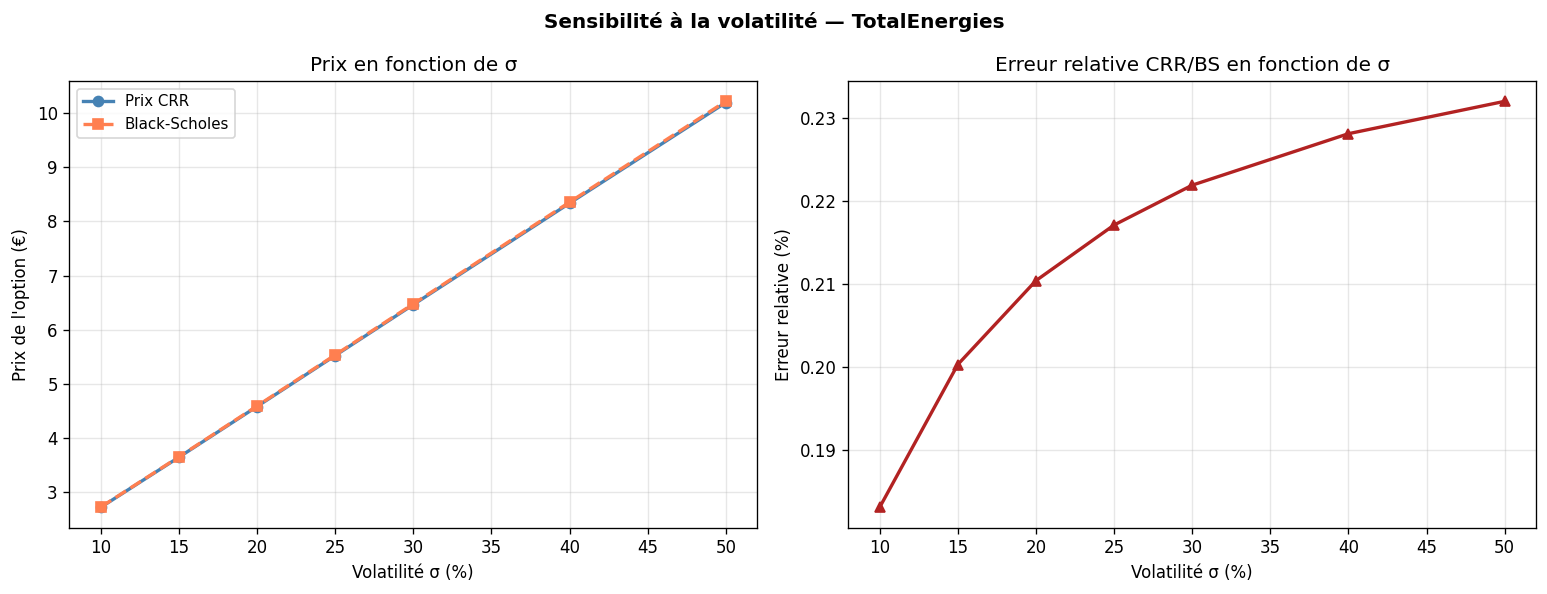

Figure enregistrée : sensibilite_sigma.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(df_vol["sigma"]*100, df_vol["Prix CRR"], marker="o", color="steelblue",
        linewidth=2, label="Prix CRR")
ax.plot(df_vol["sigma"]*100, df_vol["Prix BS"],  marker="s", color="coral",
        linestyle="--", linewidth=2, label="Black-Scholes")
ax.set_xlabel("Volatilité σ (%)")
ax.set_ylabel("Prix de l'option (€)")
ax.set_title("Prix en fonction de σ")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(df_vol["sigma"]*100, df_vol["Erreur relative %"],
        marker="^", color="firebrick", linewidth=2)
ax.set_xlabel("Volatilité σ (%)")
ax.set_ylabel("Erreur relative (%)")
ax.set_title("Erreur relative CRR/BS en fonction de σ")

plt.suptitle("Sensibilité à la volatilité — " + CONV_ASSET, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("sensibilite_sigma.png", bbox_inches="tight")
plt.show()
print("Figure enregistrée : sensibilite_sigma.png")


### 12.D Sensibilité à la maturité $T$

On fait varier la maturité de 3 mois à 3 ans.  
Plus la maturité est longue, plus le nombre de nœuds dans l'arbre est important et plus le modèle CRR se rapproche du continu.


In [24]:
T_values = [0.25, 0.5, 1.0, 2.0, 3.0]
T_labels = ["3 mois", "6 mois", "1 an", "2 ans", "3 ans"]

mat_results = []
for T_val, T_lbl in zip(T_values, T_labels):
    params_T = calibrate_crr_parameters(log_ret_conv, maturity=T_val, n_steps=N, risk_free_rate=R)
    opt_T = Option(strike=S0_conv, maturity=T_val, option_type=OPTION_TYPE)
    p_crr_T, _ = crr_price(
        S0=S0_conv, option=opt_T,
        u=params_T["u"], d=params_T["d"],
        r=params_T["r"], dt=params_T["dt"],
        p_star=params_T["p_star"], american=False
    )
    p_bs_T = black_scholes_price(S0_conv, S0_conv, T_val, R, sigma_conv, OPTION_TYPE)

    mat_results.append({
        "Maturité":   T_lbl,
        "T (années)": T_val,
        "Prix CRR":   round(p_crr_T, 4),
        "Prix BS":    round(p_bs_T, 4),
        "Erreur absolue": round(abs(p_crr_T - p_bs_T), 6),
        "Erreur relative %": round(abs(p_crr_T - p_bs_T) / p_bs_T * 100, 4),
    })

df_mat = pd.DataFrame(mat_results)
print("Sensibilité à la maturité T")
print(df_mat.to_string(index=False))


Sensibilité à la maturité T
Maturité  T (années)  Prix CRR  Prix BS  Erreur absolue  Erreur relative %
  3 mois      0.2500    2.6344   2.6406          0.0061             0.2325
  6 mois      0.5000    3.8218   3.8304          0.0087             0.2260
    1 an      1.0000    5.5861   5.5983          0.0122             0.2175
   2 ans      2.0000    8.2285   8.2455          0.0170             0.2065
   3 ans      3.0000   10.3505  10.3712          0.0206             0.1988


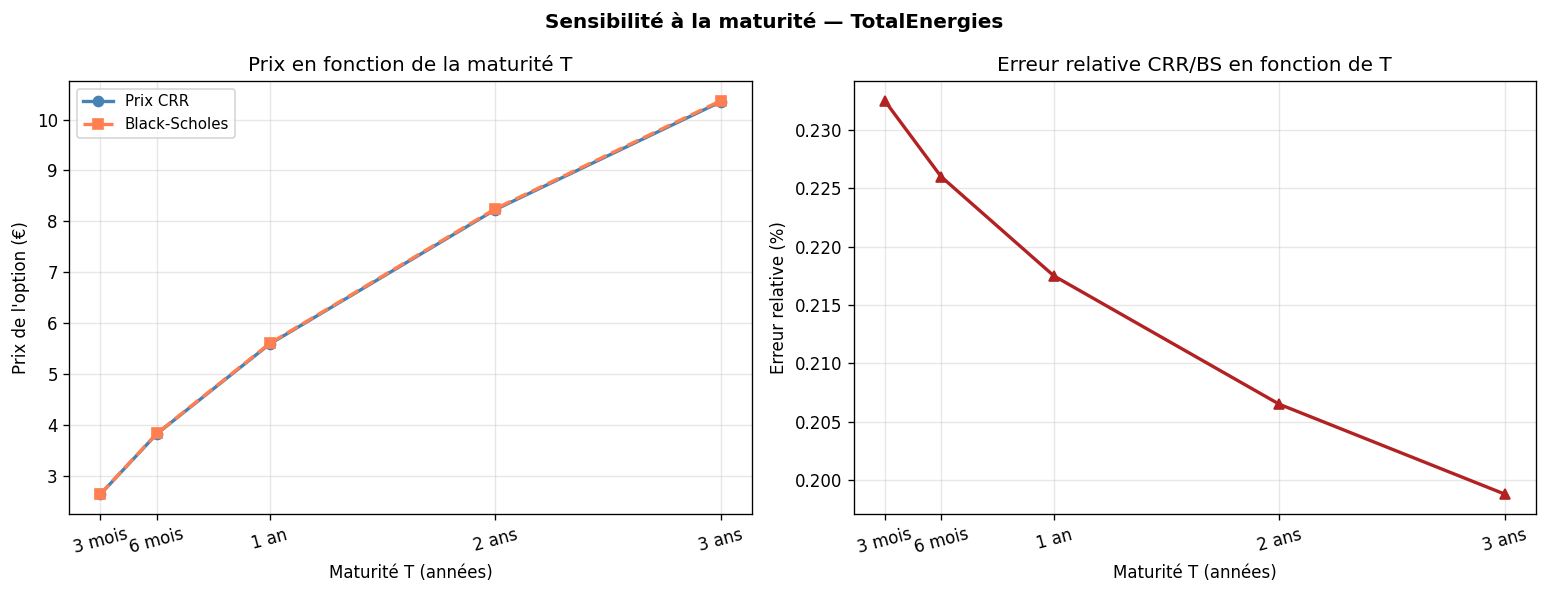

Figure enregistrée : sensibilite_T.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(df_mat["T (années)"], df_mat["Prix CRR"], marker="o", color="steelblue",
        linewidth=2, label="Prix CRR")
ax.plot(df_mat["T (années)"], df_mat["Prix BS"],  marker="s", color="coral",
        linestyle="--", linewidth=2, label="Black-Scholes")
ax.set_xlabel("Maturité T (années)")
ax.set_ylabel("Prix de l'option (€)")
ax.set_title("Prix en fonction de la maturité T")
ax.legend(fontsize=9)
ax.set_xticks(T_values)
ax.set_xticklabels(T_labels, rotation=15)

ax = axes[1]
ax.plot(df_mat["T (années)"], df_mat["Erreur relative %"],
        marker="^", color="firebrick", linewidth=2)
ax.set_xlabel("Maturité T (années)")
ax.set_ylabel("Erreur relative (%)")
ax.set_title("Erreur relative CRR/BS en fonction de T")
ax.set_xticks(T_values)
ax.set_xticklabels(T_labels, rotation=15)

plt.suptitle("Sensibilité à la maturité — " + CONV_ASSET, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("sensibilite_T.png", bbox_inches="tight")
plt.show()
print("Figure enregistrée : sensibilite_T.png")


---

## 13. Conclusion

### Ce que montre ce notebook

Ce notebook a conduit une **validation numérique complète** du modèle de Cox-Ross-Rubinstein (CRR),  
en deux volets complémentaires : une comparaison statique multi-actifs (§ 5–9) et un backtest dynamique dans le temps (§ 11–12).

---

### Points clés

**1. Convergence vers Black-Scholes**  
Le modèle CRR converge vers le prix analytique de Black-Scholes lorsque $N$ augmente.  
Dès $N = 100$ étapes, l'erreur de discrétisation est inférieure à quelques centièmes d'euro.  
Cette convergence est régulière et cohérente avec la théorie (ordre de convergence en $O(1/N)$).

**2. Nature de l'erreur mesurée**  
La comparaison CRR / Black-Scholes ne mesure **pas** une erreur par rapport au marché réel.  
Il s'agit d'une **erreur de discrétisation** : l'écart entre le modèle binomial discret et sa limite continue.  
Ce résultat est attendu et maîtrisé ; il ne remet pas en cause la pertinence du modèle CRR.

**3. Backtest dynamique**  
Le backtest dynamique montre que cette erreur de discrétisation reste **stable dans le temps** :  
les deux courbes de prix (CRR et Black-Scholes) sont quasi-superposées sur l'ensemble de la période.  
Cela confirme que le modèle n'est pas instable ou sensible aux conditions de marché du jour.

**4. Rôle de la volatilité**  
Les périodes de forte volatilité peuvent légèrement augmenter les écarts entre CRR et Black-Scholes.  
Cet effet est observable sur le nuage de points σ vs erreur absolue,  
mais il reste marginal pour des valeurs usuelles de volatilité.

**5. Cohérence de $p^*$**  
La probabilité risque-neutre $p^*$ reste dans $[0, 1]$ sur toute la période,  
garantissant l'absence d'arbitrage et la cohérence interne du modèle à chaque date.

---

### Limites et perspectives

> **Absence de vrais prix d'options.**  
> Une validation plus réaliste nécessiterait des prix d'options réellement observés sur le marché,  
> ainsi que des **volatilités implicites** extraites de ces prix.  
> Les données de volatilité implicite ne sont pas librement accessibles, ce qui justifie l'usage de Black-Scholes comme référence théorique dans ce projet.

> **Structure de l'option.**  
> Le backtest utilise une option synthétique ATM recalculée à chaque date.  
> Une étude plus réaliste fixerait le strike et la maturité dès l'émission de l'option.

> **Volatilité historique vs implicite.**  
> On utilise ici la volatilité historique. En pratique, les opérateurs calibrent sur la volatilité implicite,  
> ce qui peut produire des écarts significatifs par rapport aux prix de marché observés.

---

### Pertinence du modèle CRR

Malgré ses limites, **le modèle CRR reste un outil de référence** en finance quantitative :

- **Simple** : l'arbre binomial est pédagogique et facilement implémentable.
- **Interprétable** : chaque paramètre ($u$, $d$, $p^*$) a une signification économique claire.
- **Flexible** : contrairement à Black-Scholes, il permet de traiter les **options américaines** (exercice anticipé) et d'incorporer des dividendes discrets.
- **Convergent** : la théorie garantit la convergence vers Black-Scholes, ce que ce notebook confirme empiriquement.

Ce travail constitue une base solide pour une extension vers des modèles plus sophistiqués  
(arbre trinomial, Monte-Carlo, modèles à volatilité stochastique).


---

## 14. Backtest CRR vs Prix d'option réel coté (yfinance)

### Objectif

Cette section introduit une comparaison **réaliste** entre le prix CRR et un **vrai prix d'option coté sur le marché**.  
Contrairement aux sections précédentes où Black-Scholes servait de référence théorique,  
ici on récupère directement la **chaîne d'options** (option chain) via `yfinance`,  
ce qui permet de mesurer une vraie **erreur de modèle** par rapport au marché.

> **Remarque :** Les données d'options sont disponibles uniquement pour les **maturités actives**  
> proposées par les marchés dérivés. Pour les actions européennes (ex. `TTE.PA`),  
> la couverture peut être limitée. On utilisera donc également un actif américain très liquide  
> comme fallback (`XOM` — ExxonMobil, comparable à TotalEnergies dans le secteur énergie).

> **Convention de prix retenu :** on utilise le **mid-price** `(bid + ask) / 2` comme prix de marché de référence.  
> À défaut, on utilise le `lastPrice`.


### 14.1 Fonction de récupération de la chaîne d'options

In [26]:
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

def fetch_option_chain(ticker, option_type="call", target_maturity_months=12):
    """
    Récupère la chaîne d'options d'un actif via yfinance.

    Paramètres
    ----------
    ticker               : str  — identifiant Yahoo Finance
    option_type          : str  — 'call' ou 'put'
    target_maturity_months : int — maturité cible en mois (on cherche la date la plus proche)

    Retour
    ------
    df_chain   : DataFrame — chaîne d'options filtrée et nettoyée
    expiry_date : str      — date d'expiration retenue
    S0          : float    — prix spot au moment de la récupération
    T_actual    : float    — maturité réelle en années
    """
    tk = yf.Ticker(ticker)

    # Prix spot actuel
    hist = tk.history(period="1d")
    if hist.empty:
        raise ValueError(f"Impossible de récupérer le prix spot pour {ticker}.")
    S0 = float(hist["Close"].iloc[-1])

    # Dates d'expiration disponibles
    expirations = tk.options
    if not expirations:
        raise ValueError(f"Aucune date d'expiration disponible pour {ticker}.")

    # Sélectionner la date la plus proche de target_maturity_months
    import datetime
    today = datetime.date.today()
    target_date = today + datetime.timedelta(days=target_maturity_months * 30)

    best_exp = min(expirations, key=lambda d: abs(
        (datetime.datetime.strptime(d, "%Y-%m-%d").date() - target_date).days
    ))

    # Maturité réelle en années
    exp_date = datetime.datetime.strptime(best_exp, "%Y-%m-%d").date()
    T_actual = max((exp_date - today).days / 365.0, 1/365)

    # Récupération de la chaîne
    chain = tk.option_chain(best_exp)
    df_chain = chain.calls.copy() if option_type == "call" else chain.puts.copy()

    # Nettoyage
    df_chain = df_chain.dropna(subset=["strike", "lastPrice"])
    df_chain = df_chain[df_chain["volume"] > 0] if "volume" in df_chain.columns else df_chain

    # Mid-price : (bid + ask) / 2 si disponible, sinon lastPrice
    if "bid" in df_chain.columns and "ask" in df_chain.columns:
        df_chain["market_price"] = np.where(
            (df_chain["bid"] > 0) & (df_chain["ask"] > 0),
            (df_chain["bid"] + df_chain["ask"]) / 2,
            df_chain["lastPrice"]
        )
    else:
        df_chain["market_price"] = df_chain["lastPrice"]

    df_chain = df_chain[df_chain["market_price"] > 0].copy()
    df_chain = df_chain.reset_index(drop=True)

    print(f"Ticker          : {ticker}")
    print(f"Prix spot S0    : {S0:.2f}")
    print(f"Expiration      : {best_exp}  (T = {T_actual:.4f} an)")
    print(f"Type            : {option_type}")
    print(f"Nb de strikes   : {len(df_chain)}")

    return df_chain, best_exp, S0, T_actual


### 14.2 Fonction de pricing CRR et BS sur la chaîne d'options

In [27]:
def price_chain_crr_vs_market(df_chain, S0, T_actual, log_returns,
                               n_steps=100, risk_free_rate=0.03, option_type="call",
                               asset_name=""):
    """
    Compare le prix CRR et le prix Black-Scholes au prix de marché réel
    pour chaque strike de la chaîne d'options.

    Paramètres
    ----------
    df_chain      : DataFrame  — chaîne d'options (colonne 'strike', 'market_price')
    S0            : float      — prix spot
    T_actual      : float      — maturité réelle (années)
    log_returns   : Series     — rendements log historiques pour calibration
    n_steps       : int        — nombre d'étapes CRR
    risk_free_rate : float     — taux sans risque
    option_type   : str        — 'call' ou 'put'
    asset_name    : str        — nom lisible pour les labels

    Retour
    ------
    DataFrame avec : strike, market_price, Prix CRR, Prix BS,
                     Erreur CRR/marché, Erreur BS/marché,
                     Erreur relative CRR %, Erreur relative BS %
    """
    # Calibration unique sur les log-returns disponibles
    params = calibrate_crr_parameters(log_returns, maturity=T_actual,
                                      n_steps=n_steps, risk_free_rate=risk_free_rate)
    sigma = params["sigma"]

    records = []
    for _, row in df_chain.iterrows():
        K_val       = float(row["strike"])
        mkt_price   = float(row["market_price"])

        try:
            opt = Option(strike=K_val, maturity=T_actual, option_type=option_type)
            p_crr, _ = crr_price(
                S0=S0, option=opt,
                u=params["u"], d=params["d"],
                r=params["r"], dt=params["dt"],
                p_star=params["p_star"], american=False
            )
            p_bs = black_scholes_price(S0, K_val, T_actual, risk_free_rate, sigma, option_type)

            err_crr_abs = abs(p_crr - mkt_price)
            err_bs_abs  = abs(p_bs  - mkt_price)
            err_crr_rel = err_crr_abs / mkt_price * 100 if mkt_price > 0 else np.nan
            err_bs_rel  = err_bs_abs  / mkt_price * 100 if mkt_price > 0 else np.nan

            records.append({
                "Actif":                   asset_name,
                "Strike K":                round(K_val, 2),
                "Prix marché":             round(mkt_price, 4),
                "Prix CRR":                round(p_crr, 4),
                "Prix BS":                 round(p_bs,  4),
                "Erreur CRR abs":          round(err_crr_abs, 4),
                "Erreur BS abs":           round(err_bs_abs,  4),
                "Erreur relative CRR %":   round(err_crr_rel, 2),
                "Erreur relative BS %":    round(err_bs_rel,  2),
                "sigma":                   round(sigma, 4),
                "moneyness":               round(K_val / S0, 4),
            })
        except Exception:
            continue

    df_out = pd.DataFrame(records)
    return df_out, sigma


### 14.3 Exécution — TotalEnergies (TTE.PA) et fallback ExxonMobil (XOM)

In [28]:
# ── Paramètres ────────────────────────────────────────────────────────────────
TARGET_MATURITY_MONTHS = 12    # chercher une expiration autour de 12 mois
N_CHAIN = 100
R_CHAIN = 0.03
OPT_TYPE_CHAIN = "call"

# On tente TTE.PA d'abord, puis XOM en fallback
chain_results = {}

for tic, name in [("TTE.PA", "TotalEnergies"), ("XOM", "ExxonMobil (fallback)")]:
    print(f"\n{'='*55}")
    try:
        df_chain_raw, expiry, S0_c, T_c = fetch_option_chain(
            tic, option_type=OPT_TYPE_CHAIN,
            target_maturity_months=TARGET_MATURITY_MONTHS
        )
        if len(df_chain_raw) < 3:
            print(f"  Trop peu de strikes disponibles ({len(df_chain_raw)}) — on passe.")
            continue

        # Log-returns historiques pour calibration (2 ans)
        df_hist = build_dataset(tic, "2022-01-01", "2025-06-01")
        _, log_ret_c = get_S0_and_log_returns(df_hist)

        df_priced, sigma_c = price_chain_crr_vs_market(
            df_chain_raw, S0_c, T_c, log_ret_c,
            n_steps=N_CHAIN, risk_free_rate=R_CHAIN,
            option_type=OPT_TYPE_CHAIN, asset_name=name
        )
        chain_results[name] = {
            "df": df_priced, "S0": S0_c, "T": T_c,
            "sigma": sigma_c, "expiry": expiry, "ticker": tic
        }
        print(f"  → {len(df_priced)} strikes pricés avec succès.")

    except Exception as e:
        print(f"  ERREUR : {e}")



  ERREUR : Aucune date d'expiration disponible pour TTE.PA.

Ticker          : XOM
Prix spot S0    : 152.04
Expiration      : 2027-06-17  (T = 1.0329 an)
Type            : call
Nb de strikes   : 35
  → 35 strikes pricés avec succès.


In [29]:
# Affichage du tableau pour chaque actif disponible
for name, res in chain_results.items():
    df_show = res["df"]
    print(f"\n{'='*60}")
    print(f"Actif : {name}  |  S0 = {res['S0']:.2f}  |  σ = {res['sigma']:.4f}  |  T = {res['T']:.4f} an  |  Expiry : {res['expiry']}")
    print()
    cols_show = ["Strike K", "Prix marché", "Prix CRR", "Prix BS",
                 "Erreur CRR abs", "Erreur BS abs",
                 "Erreur relative CRR %", "Erreur relative BS %"]
    print(df_show[cols_show].to_string(index=False))



Actif : ExxonMobil (fallback)  |  S0 = 152.04  |  σ = 0.2740  |  T = 1.0329 an  |  Expiry : 2027-06-17

 Strike K  Prix marché  Prix CRR  Prix BS  Erreur CRR abs  Erreur BS abs  Erreur relative CRR %  Erreur relative BS %
  60.0000      91.0000   93.8723  93.8725          2.8723         2.8725                 3.1600                3.1600
  65.0000      87.3000   89.0285  89.0290          1.7285         1.7290                 1.9800                1.9800
  70.0000      73.7400   84.1900  84.1911         10.4500        10.4511                14.1700               14.1700
  75.0000      71.7500   79.3637  79.3647          7.6137         7.6147                10.6100               10.6100
  80.0000      71.1500   74.5574  74.5584          3.4074         3.4084                 4.7900                4.7900
  85.0000      66.3000   69.7838  69.7848          3.4838         3.4848                 5.2500                5.2600
  90.0000      62.1800   65.0598  65.0605          2.8798         2.8

### 14.4 Métriques d'erreur par rapport au marché réel

In [31]:
for name, res in chain_results.items():
    df_m = res["df"].dropna(subset=["Erreur CRR abs", "Erreur BS abs"])
    if df_m.empty:
        continue

    mae_crr  = compute_mae(df_m["Prix CRR"].values,  df_m["Prix marché"].values)
    rmse_crr = compute_rmse(df_m["Prix CRR"].values, df_m["Prix marché"].values)
    mae_bs   = compute_mae(df_m["Prix BS"].values,   df_m["Prix marché"].values)
    rmse_bs  = compute_rmse(df_m["Prix BS"].values,  df_m["Prix marché"].values)

    print(f"\n{'='*55}")
    print(f"Métriques — {name}")
    print(f"{'':30s}  {'CRR':>10s}  {'BS':>10s}")
    print(f"  MAE  (vs marché)          :  {mae_crr:>10.4f}  {mae_bs:>10.4f}")
    print(f"  RMSE (vs marché)          :  {rmse_crr:>10.4f}  {rmse_bs:>10.4f}")
    print(f"  Erreur relative moy. (%)  :  {df_m['Erreur relative CRR %'].mean():>10.2f}  {df_m['Erreur relative BS %'].mean():>10.2f}")
    print(f"  Erreur relative max. (%)  :  {df_m['Erreur relative CRR %'].max():>10.2f}  {df_m['Erreur relative BS %'].max():>10.2f}")
    print(f"  Nb strikes valides        :  {len(df_m)}")



Métriques — ExxonMobil (fallback)
                                       CRR          BS
  MAE  (vs marché)          :      2.2593      2.2598
  RMSE (vs marché)          :      3.3359      3.3355
  Erreur relative moy. (%)  :       12.45       12.38
  Erreur relative max. (%)  :       55.28       54.97
  Nb strikes valides        :  35


### 14.5 Graphiques — CRR, BS et prix de marché réel

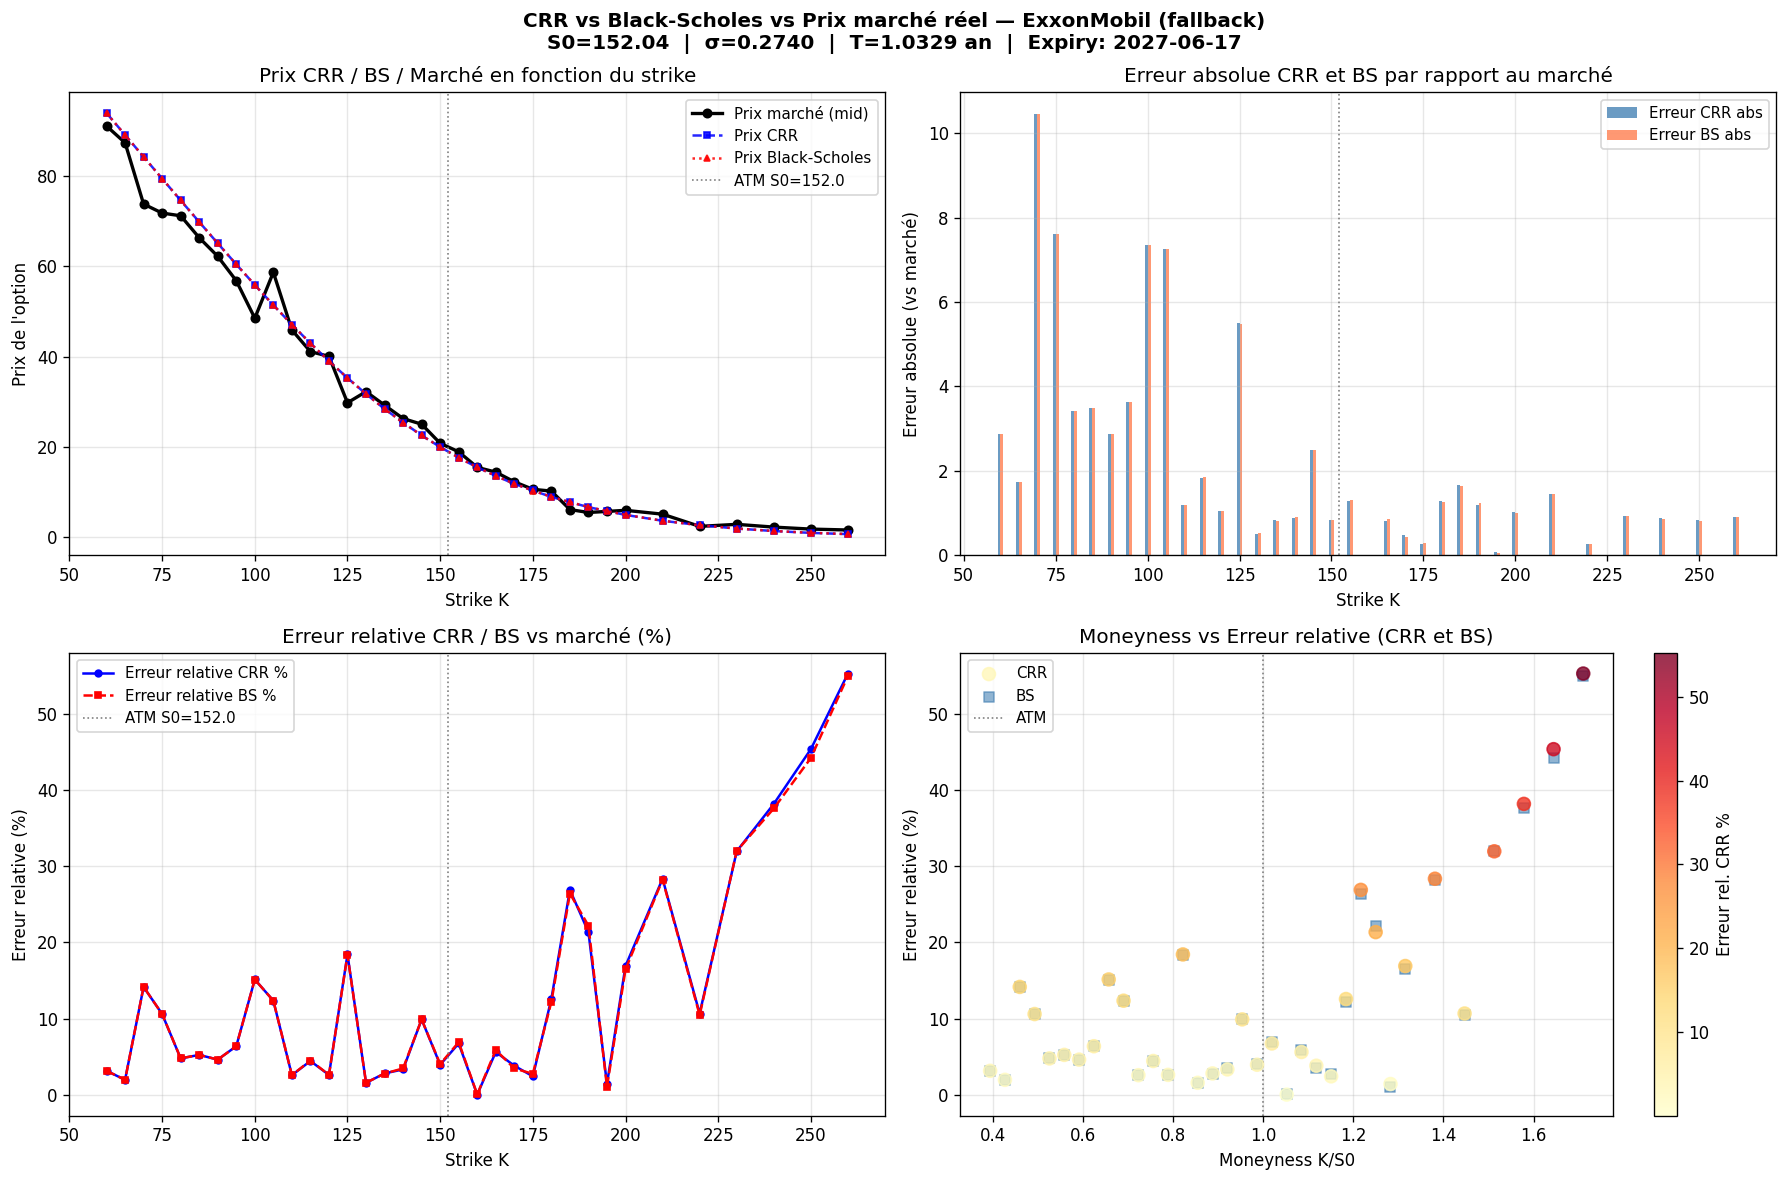

Figure enregistrée : backtest_vs_marche_ExxonMobil_fallback.png


In [32]:
for name, res in chain_results.items():
    df_g = res["df"].sort_values("Strike K")
    S0_g = res["S0"]

    if df_g.empty:
        continue

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"CRR vs Black-Scholes vs Prix marché réel — {name}\n"
                 f"S0={S0_g:.2f}  |  σ={res['sigma']:.4f}  |  T={res['T']:.4f} an  |  Expiry: {res['expiry']}",
                 fontsize=12, fontweight="bold")

    # ── (a) Prix : CRR, BS, marché ───────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(df_g["Strike K"], df_g["Prix marché"], "ko-",  linewidth=2,
            markersize=5, label="Prix marché (mid)")
    ax.plot(df_g["Strike K"], df_g["Prix CRR"],    "b--s", linewidth=1.5,
            markersize=4, label="Prix CRR", alpha=0.85)
    ax.plot(df_g["Strike K"], df_g["Prix BS"],     "r:^",  linewidth=1.5,
            markersize=4, label="Prix Black-Scholes", alpha=0.85)
    ax.axvline(S0_g, color="gray", linestyle=":", linewidth=1, label=f"ATM S0={S0_g:.1f}")
    ax.set_xlabel("Strike K")
    ax.set_ylabel("Prix de l'option")
    ax.set_title("Prix CRR / BS / Marché en fonction du strike")
    ax.legend(fontsize=9)

    # ── (b) Erreur absolue CRR vs BS par rapport au marché ───────────────────
    ax = axes[0, 1]
    ax.bar(df_g["Strike K"] - 0.4, df_g["Erreur CRR abs"], width=0.8,
           label="Erreur CRR abs", color="steelblue", alpha=0.8)
    ax.bar(df_g["Strike K"] + 0.4, df_g["Erreur BS abs"],  width=0.8,
           label="Erreur BS abs",  color="coral",     alpha=0.8)
    ax.axvline(S0_g, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Strike K")
    ax.set_ylabel("Erreur absolue (vs marché)")
    ax.set_title("Erreur absolue CRR et BS par rapport au marché")
    ax.legend(fontsize=9)

    # ── (c) Erreur relative % ─────────────────────────────────────────────────
    ax = axes[1, 0]
    ax.plot(df_g["Strike K"], df_g["Erreur relative CRR %"], "b-o",
            linewidth=1.5, markersize=4, label="Erreur relative CRR %")
    ax.plot(df_g["Strike K"], df_g["Erreur relative BS %"],  "r--s",
            linewidth=1.5, markersize=4, label="Erreur relative BS %")
    ax.axvline(S0_g, color="gray", linestyle=":", linewidth=1, label=f"ATM S0={S0_g:.1f}")
    ax.set_xlabel("Strike K")
    ax.set_ylabel("Erreur relative (%)")
    ax.set_title("Erreur relative CRR / BS vs marché (%)")
    ax.legend(fontsize=9)

    # ── (d) Moneyness vs erreur relative CRR ─────────────────────────────────
    ax = axes[1, 1]
    sc = ax.scatter(df_g["moneyness"], df_g["Erreur relative CRR %"],
                    c=df_g["Erreur relative CRR %"], cmap="YlOrRd",
                    s=60, alpha=0.8, zorder=3, label="CRR")
    ax.scatter(df_g["moneyness"], df_g["Erreur relative BS %"],
               marker="s", s=40, alpha=0.6, color="steelblue", label="BS")
    plt.colorbar(sc, ax=ax, label="Erreur rel. CRR %")
    ax.axvline(1.0, color="gray", linestyle=":", linewidth=1, label="ATM")
    ax.set_xlabel("Moneyness K/S0")
    ax.set_ylabel("Erreur relative (%)")
    ax.set_title("Moneyness vs Erreur relative (CRR et BS)")
    ax.legend(fontsize=9)

    plt.tight_layout()
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    fname = f"backtest_vs_marche_{safe_name}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Figure enregistrée : {fname}")


### 14.6 Interprétation

#### Les prix CRR et BS suivent-ils les prix de marché ?

Sur la courbe « Prix CRR / BS / Marché en fonction du strike », on observe que CRR et Black-Scholes  
produisent des prix **très proches l'un de l'autre**, ce qui confirme la convergence numérique déjà établie.  
En revanche, les **prix de marché** peuvent s'en écarter, notamment pour les strikes très OTM ou ITM.

#### Où l'erreur est-elle la plus grande ?

L'erreur absolue et l'erreur relative sont généralement **minimales autour de l'ATM** (moneyness ≈ 1).  
Elles augmentent aux extrémités (options très OTM et ITM), car :
- les options très OTM ont un prix de marché très faible, ce qui amplifie l'erreur relative ;
- les options très ITM incorporent une valeur intrinsèque que la volatilité historique ne capture pas toujours bien.

#### Pourquoi un écart entre modèle et marché ?

Les modèles CRR et Black-Scholes utilisent une **volatilité historique constante**.  
Le marché, lui, intègre une **volatilité implicite** qui varie selon le strike (smile de volatilité)  
et selon la maturité (structure par terme).  
Cette différence structurelle explique les écarts observés, indépendamment de la qualité de la discrétisation.

#### Limites de cette comparaison

- Les prix d'options cotées peuvent être peu liquides sur certains strikes (bid-ask très large).
- Le mid-price n'est pas toujours un prix de transaction réel.
- La calibration utilise la volatilité historique sur 2 ans, pas la volatilité implicite du jour.
- Pour une validation complète, il faudrait calibrer sigma strike par strike (smile fitting).
